# Predictive Maintenance of TOSHIBA Hard Drives Using SMART Attributes
### Failure Prediction (N-day horizon) + Remaining Useful Life Regression
### DNN (PyTorch) vs. XGBoost, trained across 14 Toshiba drive models

This notebook is the Toshiba counterpart of `Dataset_backblaze_Comparison.ipynb`. Three
things changed, everything else is deliberately identical so the two runs stay comparable:

1. **Data source** — the local `Toshiba/` export (105 workbooks, 3.2M drive-days,
   197 columns) instead of downloaded Backblaze quarters. Section 1 converts it once
   into `toshiba_drivestats.parquet` and reads that from then on.
2. **Input window = 90 days** — every prediction is made from a drive's trailing
   **90 days** of SMART history (raw value, 7/30/90-day deltas, and 90-day
   mean/std/max per attribute), not a single reading plus a 7-day delta.
3. **Cross-model scope** — one pooled model is trained over all 14 Toshiba families,
   and Section 16c breaks its performance down per family and runs a
   leave-one-model-out test of how well it transfers to a family it never saw.

## 1. Configuration & Data Loading

In [1]:
%pip install -q xgboost pyarrow python-calamine

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import subprocess
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from tqdm import tqdm

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
import torch
torch.manual_seed(RANDOM_STATE)

# ---- Toggle this: True = fast pipeline check on a data sample, False = full run ----
QUICK_TEST = False
QUICK_SAMPLE_N_DRIVES = 1500   # number of drives kept when QUICK_TEST is True

# ---- Data source: the local Toshiba export, not a download ----
DATA_DIR = "data"
TOSHIBA_DIR = os.path.join(DATA_DIR, "Toshiba")
DATA_PARQUET = os.path.join(DATA_DIR, "toshiba_drivestats.parquet")
BUILD_SCRIPT = os.path.join("scripts", "build_toshiba_parquet.py")

# ---- Where this notebook writes what it produces ----
MODELS_DIR = "models"     # weights (.pth/.json) + their preprocessing configs
RESULTS_DIR = "results"   # metric tables
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ---- The change that defines this notebook: the model's input is 90 days of history ----
INPUT_WINDOW_DAYS = 90        # trailing window every feature is computed over
DELTA_LAGS = (7, 30, 90)      # rate-of-change lags inside that window
MIN_WINDOW_SPAN_TOLERANCE = 5 # a 90-reading window may span at most 90+5 calendar days

FAILURE_HORIZON_DAYS = 30   # classification target: "will this drive fail within N days?"
RUL_HORIZON_DAYS = 60       # regression target window: predict RUL only within this many days of failure

# Toshiba reports a different SMART set than the Seagate drives in the sibling notebook,
# so the feature attributes are chosen from the Toshiba data itself in Section 2 rather
# than copied over. CORE = present and non-constant in all 14 families; EXTENDED = the
# same but missing entirely from the two "EY" families (see the coverage table).
CORE_ATTRS = [
    "smart_3_raw",    # Spin-Up Time
    "smart_4_raw",    # Start/Stop Count
    "smart_5_raw",    # Reallocated Sectors Count
    "smart_9_raw",    # Power-On Hours
    "smart_12_raw",   # Power Cycle Count
    "smart_192_raw",  # Power-Off Retract Count
    "smart_193_raw",  # Load/Unload Cycle Count
    "smart_194_raw",  # Temperature (Celsius)
    "smart_196_raw",  # Reallocation Event Count
    "smart_198_raw",  # Offline Uncorrectable Sector Count
    "smart_199_raw",  # UDMA CRC Error Count
]
EXTENDED_ATTRS = [
    "smart_191_raw",  # G-Sense Error Rate
    "smart_197_raw",  # Current Pending Sector Count
    "smart_220_raw",  # Disk Shift
    "smart_222_raw",  # Loaded Hours
    "smart_226_raw",  # Load-In Time
]

ID_COLUMNS = ["date", "serial_number", "model", "failure", "capacity_bytes"]

print(f"QUICK_TEST = {QUICK_TEST}")
print(f"Input window (model input):      {INPUT_WINDOW_DAYS} days")
print(f"Delta lags inside the window:    {DELTA_LAGS}")
print(f"Failure horizon (classification): {FAILURE_HORIZON_DAYS} days")
print(f"RUL horizon (regression window):  {RUL_HORIZON_DAYS} days")

QUICK_TEST = False
Input window (model input):      90 days
Delta lags inside the window:    (7, 30, 90)
Failure horizon (classification): 30 days
RUL horizon (regression window):  60 days


### 1a. One-time conversion: 105 xlsx workbooks -> one parquet file

`Toshiba/` holds 105 Excel workbooks (0.7 GB) — one folder per drive model, one
workbook per 90-day export window, 197 columns each. Reading them back with
`pd.read_excel` costs about five minutes per pass and materialises every one of the
197 columns as float64. `scripts/build_toshiba_parquet.py` converts the whole export
once into a single **34 MB parquet file** with a pinned schema, after which every
re-run of this notebook loads the same 3.2M drive-days in under a second and reads
only the columns it actually asks for.

In [3]:
if not os.path.exists(DATA_PARQUET):
    print(f"{DATA_PARQUET} not found -- building it from {TOSHIBA_DIR}/ (takes ~2 minutes) ...")
    subprocess.run(["python3", BUILD_SCRIPT], check=True)
else:
    print(f"Parquet already present: {DATA_PARQUET} "
          f"({os.path.getsize(DATA_PARQUET) / 1e6:.1f} MB)")

pf = pq.ParquetFile(DATA_PARQUET)
print(f"\nRows: {pf.metadata.num_rows:,}   Columns: {pf.metadata.num_columns}   "
      f"Row groups: {pf.metadata.num_row_groups}")

Parquet already present: toshiba_drivestats.parquet (34.5 MB)

Rows: 3,224,289   Columns: 197   Row groups: 105


In [4]:
def load_toshiba(parquet_path, attrs):
    """Read the drive-days for the requested SMART attributes out of the parquet.

    Returns a DataFrame with columns: id, time, model, failure, capacity_bytes and the
    requested SMART raw attributes -- sorted by (id, time), which every windowing
    operation downstream depends on.
    """
    df = pq.read_table(parquet_path, columns=ID_COLUMNS + attrs).to_pandas()
    df = df.rename(columns={"serial_number": "id", "date": "time"})
    df["time"] = pd.to_datetime(df["time"])
    return df.sort_values(["id", "time"]).reset_index(drop=True)


# Load every SMART raw attribute first: Section 2 needs the full picture to choose
# features, and only then does the frame get narrowed to the chosen ones.
ALL_RAW_COLUMNS = [c for c in pf.schema_arrow.names if c.endswith("_raw")]
raw_df = load_toshiba(DATA_PARQUET, ALL_RAW_COLUMNS)

if QUICK_TEST:
    # Sample within each family so every drive model still appears -- the cross-model
    # sections have nothing to compare otherwise.
    rng = np.random.RandomState(RANDOM_STATE)
    failing_ids = set(raw_df.loc[raw_df["failure"] == 1, "id"].unique())
    per_family = max(QUICK_SAMPLE_N_DRIVES // raw_df["model"].nunique(), 10)
    keep_ids = set()
    for _, grp in raw_df.groupby("model"):
        ids = grp["id"].unique()
        fail_here = [i for i in ids if i in failing_ids]
        heal_here = [i for i in ids if i not in failing_ids]
        for pool in (fail_here, heal_here):
            take = min(len(pool), per_family // 2)
            if take:
                keep_ids.update(rng.choice(pool, size=take, replace=False))
    raw_df = raw_df[raw_df["id"].isin(keep_ids)].reset_index(drop=True)
    print(f"QUICK_TEST sampling: kept {len(keep_ids)} drives "
          f"({len(keep_ids & failing_ids)} failing) across {raw_df['model'].nunique()} families")

print(f"Raw shape: {raw_df.shape}   ({raw_df.memory_usage(deep=True).sum() / 1e9:.2f} GB)")

Raw shape: (3224289, 98)   (2.61 GB)


## 2. Data Understanding

Load the raw dataset and inspect its shape, schema, date range.

In [5]:
print(f"Date range: {raw_df['time'].min().date()} -> {raw_df['time'].max().date()}")
print(f"Unique drives: {raw_df['id'].nunique():,}")
print(f"Unique models: {raw_df['model'].nunique()}")
print(f"Failure events (rows with failure==1): {int(raw_df['failure'].sum()):,}")
print(f"Drives that failed at least once: {raw_df.loc[raw_df['failure']==1, 'id'].nunique():,}")
print(f"Row-level failure rate: {100 * raw_df['failure'].mean():.4f}%")

fleet = raw_df.groupby("model").agg(
    rows=("failure", "size"),
    drives=("id", "nunique"),
    failure_events=("failure", "sum"),
    first_seen=("time", "min"),
    last_seen=("time", "max"),
)
fleet["failed_drives"] = (
    raw_df[raw_df["failure"] == 1].groupby("model")["id"].nunique()
    .reindex(fleet.index).fillna(0).astype(int)
)
fleet["failed_drive_%"] = (100 * fleet["failed_drives"] / fleet["drives"]).round(1)
fleet = fleet.sort_values("rows", ascending=False)
print("\nPer drive-model cohort (the export samples failed drives + a matched healthy group):")
print(fleet.to_string())

Date range: 2024-01-01 -> 2026-03-31
Unique drives: 5,589
Unique models: 14
Failure events (rows with failure==1): 2,746
Drives that failed at least once: 2,736
Row-level failure rate: 0.0852%



Per drive-model cohort (the export samples failed drives + a matched healthy group):
                         rows  drives  failure_events first_seen  last_seen  failed_drives  failed_drive_%
model                                                                                                     
TOSHIBA MG07ACA14TA   1144669    1882             941 2024-01-01 2026-03-31            941            50.0
TOSHIBA MG08ACA16TA   1121326    1896             948 2024-01-01 2026-03-31            948            50.0
TOSHIBA MG08ACA16TEY   555435     832             426 2024-01-01 2026-03-31            416            50.0
TOSHIBA MG08ACA16TE    201993     336             168 2024-01-01 2026-03-31            168            50.0
TOSHIBA MG10ACA20TE     94223     274             137 2024-01-01 2026-03-31            137            50.0
TOSHIBA MG07ACA14TEY    34717      70              35 2024-01-01 2026-03-31             35            50.0
TOSHIBA MQ01ABF050M     34418      80              40 2024

### 2a. Which SMART attributes do Toshiba drives actually report?

The sibling Backblaze notebook hard-codes nine Seagate attributes. Copying that list
here would be wrong: `smart_187` (Reported Uncorrectable Errors), `smart_188`
(Command Timeout) and `smart_241` (Total LBAs Written) are **not reported at all** by
these Toshiba families, while attributes that Seagate leaves empty carry the signal
here. Worse, coverage is not even uniform *within* Toshiba — so the feature list is
derived from the data, and the per-family table below is what justifies the split
between `CORE_ATTRS` and `EXTENDED_ATTRS`.

In [6]:
coverage = raw_df[ALL_RAW_COLUMNS].notna().mean()
n_distinct = raw_df[ALL_RAW_COLUMNS].nunique()

attr_table = pd.DataFrame({
    "coverage_%": (100 * coverage).round(1),
    "distinct_values": n_distinct,
})
attr_table["usable"] = (attr_table["coverage_%"] >= 50) & (attr_table["distinct_values"] > 1)

reported = attr_table[attr_table["coverage_%"] >= 50].sort_values("coverage_%", ascending=False)
print(f"{len(ALL_RAW_COLUMNS)} SMART raw attributes in the export; "
      f"{int(attr_table['usable'].sum())} are both well-covered and non-constant.\n")
print("Attributes reported by at least half the Toshiba fleet:")
print(reported.to_string())

constant = attr_table[(attr_table["coverage_%"] >= 50) & (attr_table["distinct_values"] <= 1)].index.tolist()
print(f"\nReported but CONSTANT across the whole fleet (no information, dropped): "
      f"{[c.replace('smart_', 'S').replace('_raw', '') for c in constant]}")

seagate_only = ["smart_187_raw", "smart_188_raw", "smart_241_raw"]
print("\nAttributes the Backblaze/Seagate notebook relies on, and their Toshiba coverage:")
for c in seagate_only:
    pct = 100 * coverage.get(c, 0.0)
    print(f"  {c:16s}: {pct:5.1f}%  {'-> not reported by Toshiba' if pct < 1 else ''}")

93 SMART raw attributes in the export; 16 are both well-covered and non-constant.

Attributes reported by at least half the Toshiba fleet:
               coverage_%  distinct_values  usable
smart_1_raw         100.0                1   False
smart_9_raw         100.0            75761    True
smart_199_raw       100.0              673    True
smart_198_raw       100.0              326    True
smart_194_raw       100.0               52    True
smart_193_raw       100.0             2233    True
smart_12_raw        100.0              484    True
smart_192_raw       100.0              486    True
smart_7_raw         100.0                1   False
smart_5_raw         100.0             4183    True
smart_4_raw         100.0              486    True
smart_3_raw         100.0             2982    True
smart_10_raw         99.9                1   False
smart_2_raw          99.9                1   False
smart_196_raw        99.9             2553    True
smart_8_raw          99.9                1   

In [7]:
# Per-family coverage: the reason EXTENDED_ATTRS is a separate list.
usable_attrs = attr_table.index[attr_table["usable"]].tolist()
usable_attrs = sorted(usable_attrs, key=lambda c: int(c.split("_")[1]))

per_model_cov = raw_df.groupby("model")[usable_attrs].apply(lambda g: g.notna().mean())
per_model_cov.columns = [c.replace("smart_", "S").replace("_raw", "") for c in per_model_cov.columns]
print("Per-family coverage of the usable attributes (% of rows non-null):")
print((100 * per_model_cov).round(0).astype(int).to_string())

ATTRS = CORE_ATTRS + EXTENDED_ATTRS
missing_from_export = [c for c in ATTRS if c not in raw_df.columns]
assert not missing_from_export, f"configured attributes absent from the export: {missing_from_export}"
print(f"\nCORE_ATTRS     ({len(CORE_ATTRS)}): reported by all 14 families")
print(f"EXTENDED_ATTRS ({len(EXTENDED_ATTRS)}): missing from the two 'EY' families -> median-imputed there,")
print( "                    which the one-hot drive-model feature lets the models account for.")
print(f"\nUsing {len(ATTRS)} SMART attributes as the base for the {INPUT_WINDOW_DAYS}-day window features.")

# Narrow the frame now that the feature attributes are settled: the other ~77 raw
# columns are constant, empty, or both, and holding them costs ~2 GB for nothing.
raw_df = raw_df[["id", "time", "model", "failure", "capacity_bytes"] + ATTRS]
print(f"raw_df narrowed to {raw_df.shape[1]} columns "
      f"({raw_df.memory_usage(deep=True).sum() / 1e9:.2f} GB)")

Per-family coverage of the usable attributes (% of rows non-null):
                       S3   S4   S5   S9  S12  S191  S192  S193  S194  S196  S197  S198  S199  S220  S222  S226
model                                                                                                          
TOSHIBA HDWE160       100  100  100  100  100   100   100   100   100   100   100   100   100   100   100   100
TOSHIBA HDWF180       100  100  100  100  100   100   100   100   100   100   100   100   100   100   100   100
TOSHIBA MD04ABA400V   100  100  100  100  100   100   100   100   100   100   100   100   100   100   100   100
TOSHIBA MG07ACA14TA   100  100  100  100  100   100   100   100   100   100   100   100   100   100   100   100
TOSHIBA MG07ACA14TEY  100  100  100  100  100     0   100   100   100   100     0   100   100     0     0     0
TOSHIBA MG08ACA16TA   100  100  100  100  100   100   100   100   100   100   100   100   100   100   100   100
TOSHIBA MG08ACA16TE   100  100  100  

raw_df narrowed to 21 columns (0.62 GB)


In [8]:
# Reading cadence -- the 90-day window is built positionally (90 consecutive readings),
# which is only equivalent to 90 calendar days if reporting really is daily. Verify it,
# and note the tolerance check that Section 4 applies per row regardless.
gaps = raw_df.groupby("id", sort=False)["time"].diff().dt.days
daily_share = (gaps == 1).sum() / gaps.notna().sum()
print(f"Consecutive readings exactly 1 day apart: {100 * daily_share:.3f}%")
print(f"Duplicate (drive, date) rows: {int(raw_df.duplicated(['id', 'time']).sum())}")
print("\nGap distribution (days between consecutive readings):")
print(gaps.value_counts().head(5).to_string())

per_drive = raw_df.groupby("id")["time"].agg(["count", "min", "max"])
print(f"\nReadings per drive: median {per_drive['count'].median():.0f}, "
      f"p10 {per_drive['count'].quantile(0.1):.0f}, p90 {per_drive['count'].quantile(0.9):.0f}")
print(f"Drives with at least {INPUT_WINDOW_DAYS + 1} readings (eligible for a full window): "
      f"{int((per_drive['count'] >= INPUT_WINDOW_DAYS + 1).sum()):,} / {len(per_drive):,}")

Consecutive readings exactly 1 day apart: 99.904%


Duplicate (drive, date) rows: 0

Gap distribution (days between consecutive readings):
time
1.0    3215622
2.0       1248
3.0       1177
4.0        109
5.0        108



Readings per drive: median 678, p10 135, p90 821
Drives with at least 91 readings (eligible for a full window): 5,170 / 5,589


## 3. Exploratory Data Analysis (EDA)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

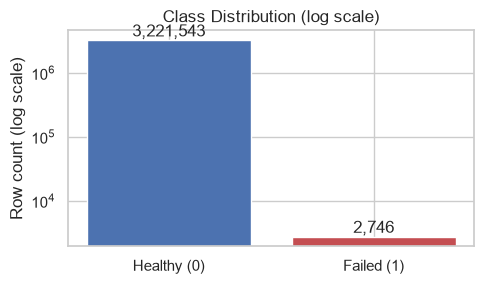

Imbalance ratio (healthy : failed) approx 1,173 : 1
This ratio is why threshold=0.5 and plain accuracy are misleading metrics here.
Note this counts raw failure FLAGS (one row per drive). Section 5 labels the whole
30-day run-up to each failure positive, which softens the ratio considerably.


In [10]:
vc = raw_df["failure"].value_counts()
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["Healthy (0)", "Failed (1)"], [vc.get(0, 0), vc.get(1, 0)], color=["#4C72B0", "#C44E52"])
ax.set_yscale("log")
ax.set_title("Class Distribution (log scale)")
ax.set_ylabel("Row count (log scale)")
for i, v in enumerate([vc.get(0, 0), vc.get(1, 0)]):
    ax.text(i, v * 1.15, f"{v:,}", ha="center")
plt.tight_layout()
plt.show()
ratio = vc.get(0, 0) / max(vc.get(1, 1), 1)
print(f"Imbalance ratio (healthy : failed) approx {ratio:,.0f} : 1")
print("This ratio is why threshold=0.5 and plain accuracy are misleading metrics here.")
print("Note this counts raw failure FLAGS (one row per drive). Section 5 labels the whole")
print(f"{FAILURE_HORIZON_DAYS}-day run-up to each failure positive, which softens the ratio considerably.")

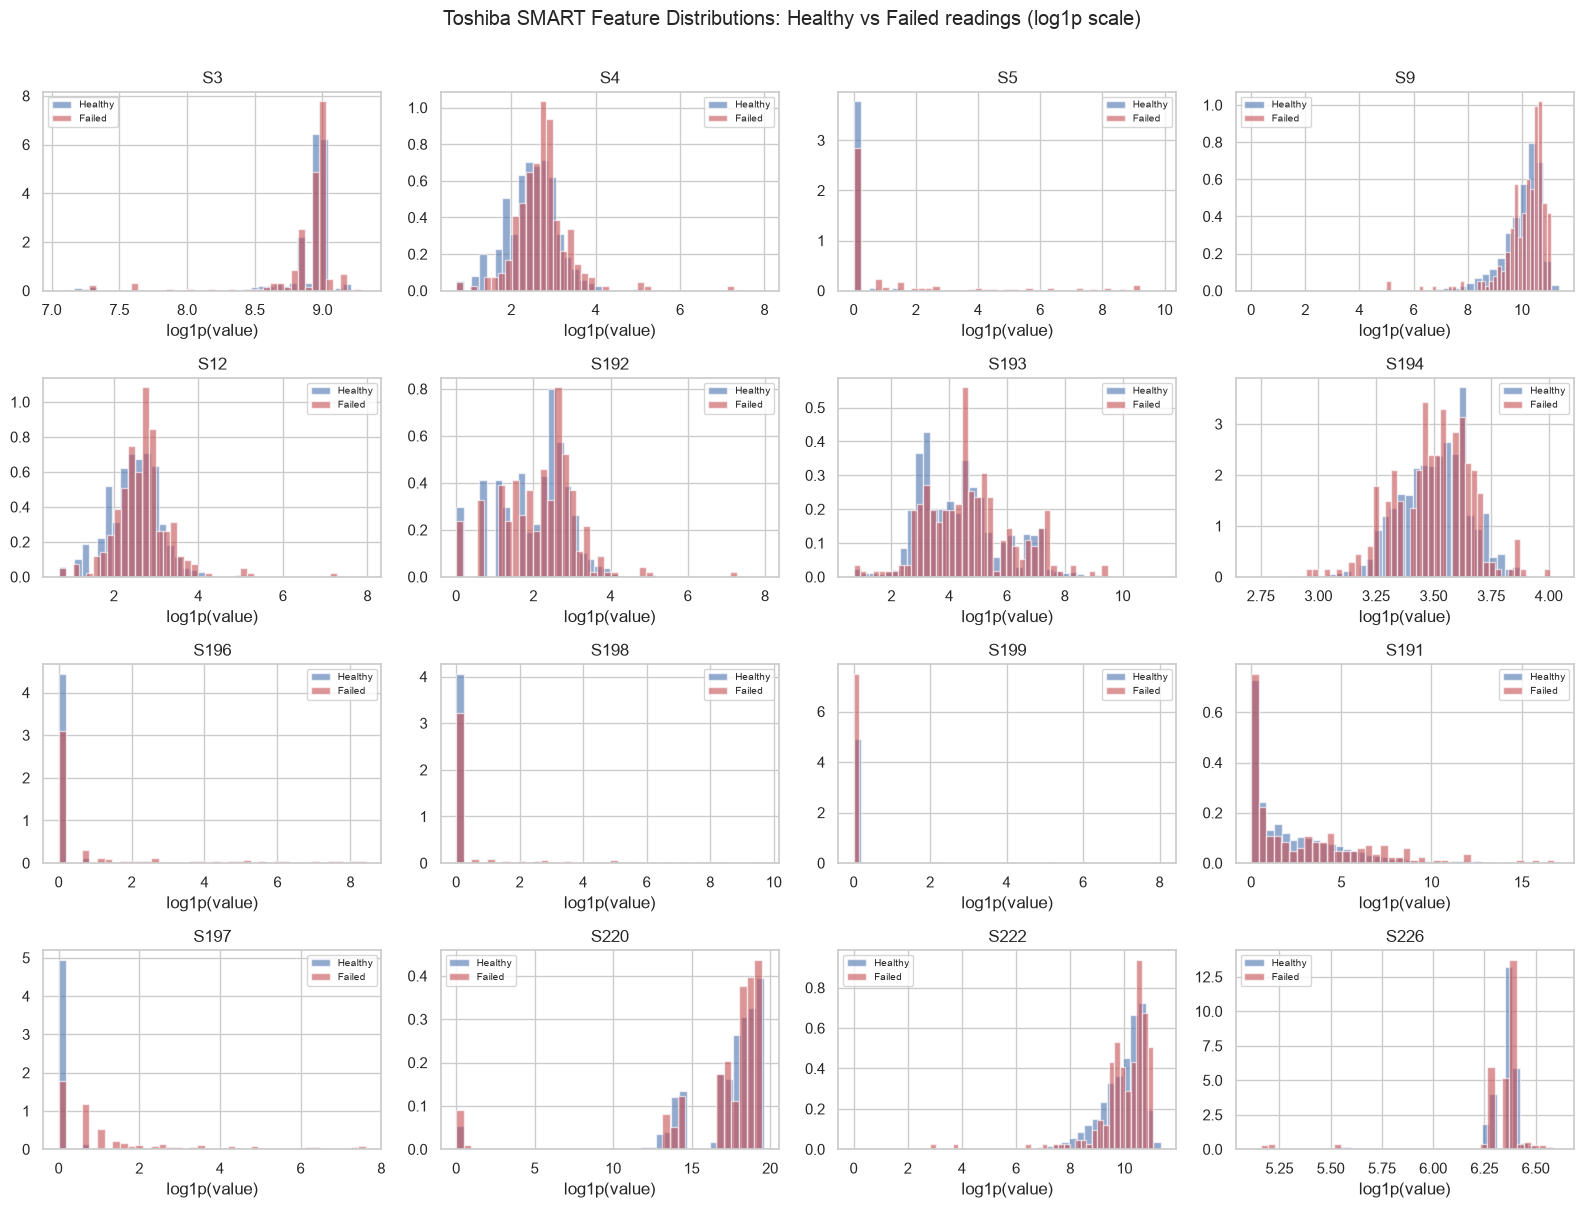

In [11]:
sample_df = raw_df.sample(min(300_000, len(raw_df)), random_state=RANDOM_STATE)
n = len(ATTRS)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()
for i, col in enumerate(ATTRS):
    for label, color in [(0, "#4C72B0"), (1, "#C44E52")]:
        vals = sample_df.loc[sample_df["failure"] == label, col].dropna()
        if len(vals) == 0:
            continue
        vals = np.log1p(vals.clip(lower=0))
        axes[i].hist(vals, bins=40, alpha=0.6, color=color,
                     label=["Healthy", "Failed"][label], density=True)
    axes[i].set_title(col.replace("smart_", "S").replace("_raw", ""))
    axes[i].set_xlabel("log1p(value)")
    axes[i].legend(fontsize=7)
for j in range(n, len(axes)):
    axes[j].set_visible(False)
fig.suptitle("Toshiba SMART Feature Distributions: Healthy vs Failed readings (log1p scale)", y=1.005)
plt.tight_layout()
plt.show()

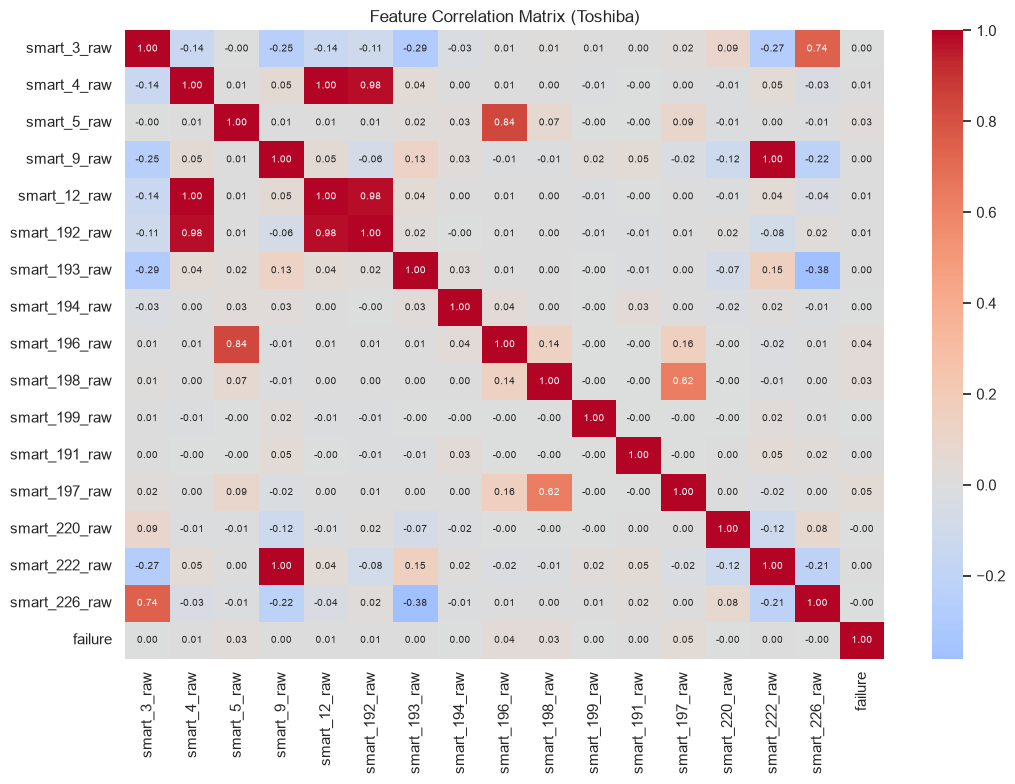

In [12]:
corr = raw_df[ATTRS + ["failure"]].corr()
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, annot_kws={"size": 7})
ax.set_title("Feature Correlation Matrix (Toshiba)")
plt.tight_layout()
plt.show()

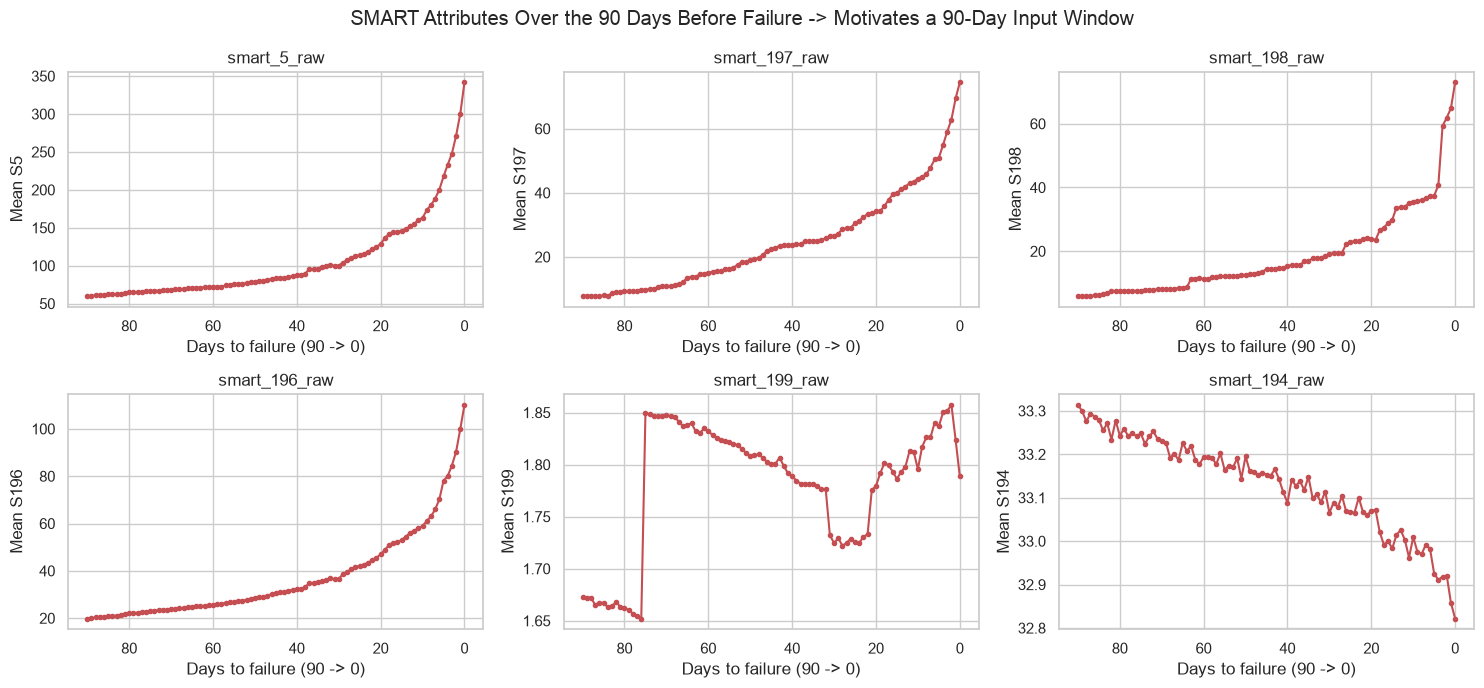

In [13]:
# --- Trend analysis: how do SMART values evolve as failure approaches? ---
# This is the empirical justification for the 90-day window features in Section 4:
# if the attributes only move in the last handful of days, a 90-day input buys nothing.
failing_ids_eda = raw_df.loc[raw_df["failure"] == 1, "id"].unique()
trend_df = raw_df[raw_df["id"].isin(failing_ids_eda)].copy()
last_date = trend_df.groupby("id")["time"].transform("max")
trend_df["days_to_failure"] = (last_date - trend_df["time"]).dt.days
trend_df = trend_df[trend_df["days_to_failure"] <= INPUT_WINDOW_DAYS]

trend_attrs = ["smart_5_raw", "smart_197_raw", "smart_198_raw", "smart_196_raw",
               "smart_199_raw", "smart_194_raw"]
trend_attrs = [c for c in trend_attrs if c in trend_df.columns]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flatten(), trend_attrs):
    agg = trend_df.groupby("days_to_failure")[col].mean().sort_index(ascending=False)
    ax.plot(agg.index, agg.values, marker="o", ms=3, color="#C44E52")
    ax.invert_xaxis()
    ax.set_xlabel(f"Days to failure ({INPUT_WINDOW_DAYS} -> 0)")
    ax.set_ylabel(f"Mean {col.replace('smart_', 'S').replace('_raw', '')}")
    ax.set_title(col)
for j in range(len(trend_attrs), 6):
    axes.flatten()[j].set_visible(False)
fig.suptitle(f"SMART Attributes Over the {INPUT_WINDOW_DAYS} Days Before Failure "
             f"-> Motivates a {INPUT_WINDOW_DAYS}-Day Input Window")
plt.tight_layout()
plt.show()

## 4. Feature Engineering — the 90-Day Input Window

This is the substantive difference from the Backblaze notebook. There, one prediction
saw one reading plus a single 7-day delta. Here every prediction sees the drive's
trailing **90 days**, summarised per SMART attribute as:

| feature | what it captures |
|---|---|
| `<attr>` | the current reading (level) |
| `<attr>_d7`, `_d30`, `_d90` | change over 7 / 30 / 90 days (rate of change at three timescales) |
| `<attr>_mean90` | the window average (level, denoised) |
| `<attr>_std90` | volatility inside the window |
| `<attr>_max90` | the worst value seen in the window — a spike that later recovered is still evidence |

Plus three window-level features: how many calendar days the 90 readings actually
span, the drive's age at prediction time, and its capacity; and a one-hot of the drive
model, which is what lets a single pooled model serve 14 families with different SMART
semantics.

The window is built **positionally** (90 consecutive readings) because Section 2
showed 99.9% of readings are exactly one day apart. The 0.1% that are not would
silently stretch a "90-day" window across a longer span, so every row also carries the
real calendar span of its window and rows exceeding the tolerance are dropped below.

In [14]:
W = INPUT_WINDOW_DAYS
df_feat = raw_df.sort_values(["id", "time"]).reset_index(drop=True)
grouped = df_feat.groupby("id", sort=False)

window_features = {}

# Level: the current reading.
for c in ATTRS:
    window_features[c] = df_feat[c]

# Rate of change at three timescales inside the window.
for lag in DELTA_LAGS:
    diffs = grouped[ATTRS].diff(lag)
    for c in ATTRS:
        window_features[f"{c}_d{lag}"] = diffs[c]

# Distribution of each attribute across the window.
rolling = grouped[ATTRS].rolling(W, min_periods=1)
for stat in ("mean", "std", "max"):
    vals = getattr(rolling, stat)().reset_index(level=0, drop=True)
    for c in ATTRS:
        window_features[f"{c}_{stat}{W}"] = vals[c]
    print(f"  rolling {stat}{W} done")

X_window = pd.DataFrame(window_features, index=df_feat.index)

# Window-level context.
# The window is today plus the 90 preceding days = 91 readings: the 90-day delta
# needs the reading from exactly 90 days ago, and the rolling statistics cover the
# 90 readings up to and including today.
readings_so_far = grouped.cumcount() + 1
window_span_days = grouped["time"].diff(W).dt.days
X_window["window_span_days"] = window_span_days
X_window["drive_age_days"] = (df_feat["time"] - grouped["time"].transform("min")).dt.days
X_window["capacity_tb"] = df_feat["capacity_bytes"] / 1e12

ATTR_FEATURE_COLUMNS = [c for c in X_window.columns]
print(f"\n{len(ATTRS)} attributes x {1 + len(DELTA_LAGS) + 3} window statistics "
      f"+ 3 context features = {len(ATTR_FEATURE_COLUMNS)} features")

  rolling mean90 done


  rolling std90 done


  rolling max90 done



16 attributes x 7 window statistics + 3 context features = 115 features


In [15]:
# One-hot the drive model: a single pooled model has to know which family it is looking
# at, because the same SMART attribute does not mean the same thing across families
# (and EXTENDED_ATTRS are absent for two of them entirely).
model_dummies = pd.get_dummies(df_feat["model"], prefix="model").astype(np.float64)
MODEL_FEATURE_COLUMNS = list(model_dummies.columns)
X_window = pd.concat([X_window, model_dummies], axis=1)

FEATURE_COLUMNS = ATTR_FEATURE_COLUMNS + MODEL_FEATURE_COLUMNS
print(f"Total feature count: {len(FEATURE_COLUMNS)} "
      f"({len(ATTR_FEATURE_COLUMNS)} window features + {len(MODEL_FEATURE_COLUMNS)} drive-model one-hots)")

Total feature count: 129 (115 window features + 14 drive-model one-hots)


In [16]:
# Enforce "the input is 90 days": keep only rows that really have a full window behind
# them. A row with 40 readings of history is not a 90-day input, and letting it through
# with median-filled deltas is exactly the kind of quiet dilution that makes a model
# look better in validation than it is in production.
full_window = (readings_so_far >= W + 1) & (window_span_days <= W + MIN_WINDOW_SPAN_TOLERANCE)
full_window = full_window.fillna(False)

print(f"Rows before window filter: {len(df_feat):,}")
print(f"  dropped, fewer than {W + 1} readings of history: {int((readings_so_far < W + 1).sum()):,}")
print(f"  dropped, window spans more than {W + MIN_WINDOW_SPAN_TOLERANCE} calendar days "
      f"(reporting gaps): {int(((readings_so_far >= W + 1) & ~full_window).sum()):,}")
print(f"Rows after window filter:  {int(full_window.sum()):,} "
      f"({100 * full_window.mean():.1f}%)")
print(f"Drives surviving the filter: {df_feat.loc[full_window, 'id'].nunique():,} "
      f"/ {df_feat['id'].nunique():,}")

nan_share = X_window.loc[full_window, ATTR_FEATURE_COLUMNS].isna().mean()
print(f"\nRemaining NaN share after the filter (attributes absent for a family, "
      f"not missing history): {100 * nan_share.mean():.2f}% of cells")
print("Worst offenders:")
print((100 * nan_share.sort_values(ascending=False).head(5)).round(1).to_string())

Rows before window filter: 3,224,289
  dropped, fewer than 91 readings of history: 479,113
  dropped, window spans more than 95 calendar days (reporting gaps): 12,425
Rows after window filter:  2,732,751 (84.8%)


Drives surviving the filter: 5,169 / 5,589



Remaining NaN share after the filter (attributes absent for a family, not missing history): 5.67% of cells
Worst offenders:
smart_226_raw_d90    18.6
smart_222_raw_d90    18.6
smart_220_raw_d90    18.6
smart_191_raw_d90    18.6
smart_197_raw_d90    18.6


## 5. Data Preprocessing

Three steps:
1. **Target engineering** — binary "at-risk" label: 1 if the drive fails within the
   next `FAILURE_HORIZON_DAYS` days, else 0.
2. **Leakage-free split** — split by *drive ID* with `GroupShuffleSplit` so no drive's
   readings appear in more than one partition (otherwise the model could "memorize"
   a drive it partially saw in training). With 90-day windows this matters even more
   than it did with 7-day deltas: consecutive rows of one drive share 89 of their 90
   days, so a row-level split would put near-copies of the same window on both sides.
3. **Imputation & scaling** — median imputation, then `StandardScaler`, both fit on
   the training set only.

In [17]:
def engineer_target(df, window_days):
    """Binary label: 1 if this row is within `window_days` of that drive's failure date."""
    failure_dates = df.loc[df["failure"] == 1].groupby("id")["time"].max()
    failure_date = df["id"].map(failure_dates)
    days_to_failure = (failure_date - df["time"]).dt.days
    target = days_to_failure.between(0, window_days).astype(np.int8)
    return days_to_failure, target


days_to_failure, target = engineer_target(df_feat, FAILURE_HORIZON_DAYS)
df_feat["days_to_failure"] = days_to_failure
df_feat["target"] = target

# Apply the 90-day window filter to features, labels and groups together.
X_all = X_window.loc[full_window].reset_index(drop=True)
meta_all = df_feat.loc[full_window, ["id", "time", "model", "failure",
                                     "days_to_failure", "target"]].reset_index(drop=True)
del X_window, window_features
y_all = meta_all["target"]

print(f"Modelling set: {X_all.shape[0]:,} rows x {X_all.shape[1]} features")
print(f"Positive rate at a {FAILURE_HORIZON_DAYS}-day horizon: "
      f"{100 * y_all.mean():.4f}%  ({int(y_all.sum()):,} / {len(y_all):,} rows)")
print(f"Imbalance ratio: {(y_all == 0).sum() / max(y_all.sum(), 1):,.0f} : 1")

Modelling set: 2,732,751 rows x 129 features
Positive rate at a 30-day horizon: 2.5514%  (69,724 / 2,732,751 rows)
Imbalance ratio: 38 : 1


In [18]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

groups = meta_all["id"]

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_val_idx, test_idx = next(gss1.split(X_all, groups=groups))

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
tv_train_idx, tv_val_idx = next(gss2.split(X_all.iloc[train_val_idx],
                                            groups=groups.iloc[train_val_idx]))
# Sorted so that every split keeps meta_all's original row order. Section 16c builds
# per-family boolean masks over meta_all and indexes the test-set probability vectors
# with them; if test_idx came back shuffled those two orderings would silently disagree.
train_idx = np.sort(train_val_idx[tv_train_idx])
val_idx = np.sort(train_val_idx[tv_val_idx])
test_idx = np.sort(test_idx)

train_meta, val_meta, test_meta = meta_all.iloc[train_idx], meta_all.iloc[val_idx], meta_all.iloc[test_idx]

for name, idx in [("Train", train_idx), ("Val", val_idx), ("Test", test_idx)]:
    m = meta_all.iloc[idx]
    print(f"{name:5s}: {len(idx):>9,} rows, {m['id'].nunique():>5,} drives, "
          f"{int(m['target'].sum()):>6,} positives ({100 * m['target'].mean():.3f}%)")

train_ids, val_ids, test_ids = (set(meta_all.iloc[i]["id"]) for i in (train_idx, val_idx, test_idx))
assert train_ids & val_ids == set()
assert train_ids & test_ids == set()
assert val_ids & test_ids == set()
print("\nNo drive appears in more than one split (leakage check passed).")

Train: 1,841,518 rows, 3,514 drives, 47,908 positives (2.602%)
Val  :   327,604 rows,   621 drives,  8,340 positives (2.546%)
Test :   563,629 rows, 1,034 drives, 13,476 positives (2.391%)



No drive appears in more than one split (leakage check passed).


In [19]:
X_train, y_train = X_all.iloc[train_idx], y_all.iloc[train_idx]
X_val, y_val = X_all.iloc[val_idx], y_all.iloc[val_idx]
X_test, y_test = X_all.iloc[test_idx], y_all.iloc[test_idx]

imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_val_imp = imputer.transform(X_val)
X_test_imp = imputer.transform(X_test)

scaler = StandardScaler()
# Scaling is done in float64 (smart_220_raw reaches 3e8, past the point where float32
# represents integers exactly) and only the scaled, O(1) result is cast down to float32
# for torch -- which halves the memory the three matrices hold.
X_train_scaled = scaler.fit_transform(X_train_imp).astype(np.float32)
X_val_scaled = scaler.transform(X_val_imp).astype(np.float32)
X_test_scaled = scaler.transform(X_test_imp).astype(np.float32)

n_pos, n_neg = int(y_train.sum()), int((y_train == 0).sum())
POS_WEIGHT = n_neg / max(n_pos, 1)
print(f"Training set -> positives: {n_pos:,}  negatives: {n_neg:,}  pos_weight: {POS_WEIGHT:.1f}")
print(f"Scaled matrices: train {X_train_scaled.shape}, val {X_val_scaled.shape}, test {X_test_scaled.shape}")

Training set -> positives: 47,908  negatives: 1,793,610  pos_weight: 37.4
Scaled matrices: train (1841518, 129), val (327604, 129), test (563629, 129)


## 6. Handling Class Imbalance

In [20]:
from torch.utils.data import WeightedRandomSampler

class_sample_count = np.array([n_neg, n_pos])
weight_per_class = 1.0 / class_sample_count
sample_weights = weight_per_class[y_train.values.astype(int)]
sample_weights = torch.tensor(sample_weights, dtype=torch.double)

train_sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)
print("WeightedRandomSampler ready. Dataset size is UNCHANGED "
      f"({len(sample_weights):,} rows) -- only the sampling probability is adjusted.")

# The sampler already draws the two classes in equal proportion, so each batch the BCE
# loss sees is balanced. Passing pos_weight=POS_WEIGHT on top of that would correct the
# same imbalance twice -- a ~34x over-correction that drives every probability toward 1
# and forces the tuned threshold up to 0.99, which looks like a threshold problem but is
# really a loss-weighting bug. XGBoost has no sampler, so it still gets the full
# POS_WEIGHT via scale_pos_weight in Section 16b.
BCE_POS_WEIGHT = 1.0
print(f"BCE pos_weight with the sampler in use: {BCE_POS_WEIGHT} "
      f"(raw class ratio {POS_WEIGHT:.1f} goes to XGBoost, which has no sampler)")

WeightedRandomSampler ready. Dataset size is UNCHANGED (1,841,518 rows) -- only the sampling probability is adjusted.
BCE pos_weight with the sampler in use: 1.0 (raw class ratio 37.4 goes to XGBoost, which has no sampler)


## 7. PyTorch Dataset & DataLoader

In [21]:
from torch import nn
from torch.utils.data import Dataset, DataLoader

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

BATCH_SIZE = 2048
NUM_WORKERS = 0  # 0 deliberately: spawn-based workers cannot pickle the Dataset classes
                 # defined in this kernel (macOS / Python 3.14), and with the tensors
                 # already resident in RAM they add overhead rather than removing it.


class DriveDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(np.ascontiguousarray(X, dtype=np.float32))
        y_arr = y.values if hasattr(y, "values") else y
        self.y = torch.tensor(np.asarray(y_arr, dtype=np.float32)).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = DriveDataset(X_train_scaled, y_train)
val_dataset = DriveDataset(X_val_scaled, y_val)
test_dataset = DriveDataset(X_test_scaled, y_test)

# Two training loaders so Section 10 can compare imbalance strategies head to head
# rather than assuming the sampler is the right one: `balanced` resamples the classes
# to parity, `plain` leaves the natural 38:1 ratio and lets the loss do the correcting.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler,
                          num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"))
train_loader_plain = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                                num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"))

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, "
      f"Test batches: {len(test_loader)}")

Using device: mps


Train batches: 900, Val batches: 160, Test batches: 276


## 8. Model Architecture

`DriveFailureDNN` is a configurable feed-forward network: `Linear -> BatchNorm ->
ReLU -> Dropout`, repeated, ending in a single logit for `BCEWithLogitsLoss`.
`FocalLoss` is implemented as an alternative loss function to compare against
class-weighted BCE. Identical to the Backblaze notebook, so any difference in the
results traces to the data and the 90-day input rather than to the architecture.

In [22]:
class DriveFailureDNN(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_sizes:
            layers += [nn.Linear(prev_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class FocalLoss(nn.Module):
    """Focal loss for binary classification with logits.

    Down-weights easy (already well-classified) examples via (1-pt)**gamma so training
    focuses on hard/minority examples -- an alternative to class-weighted resampling.
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt = probs * targets + (1 - probs) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss = alpha_t * (1 - pt).pow(self.gamma) * bce
        return loss.mean()


_tmp = DriveFailureDNN(input_dim=len(FEATURE_COLUMNS)).to(device)
print(_tmp)
del _tmp

DriveFailureDNN(
  (net): Sequential(
    (0): Linear(in_features=129, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 9. Training & Validation Function

`run_training()` trains with early stopping on **validation PR-AUC** (far more
informative than loss or accuracy on a dataset this imbalanced) and supports both loss
types so the same function powers the hyperparameter grid (Section 10) and the final
model (Section 11).

In [23]:
from sklearn.metrics import average_precision_score, f1_score
import copy
import time


def evaluate_loader(model, loader, criterion):
    model.eval()
    total_loss, all_probs, all_targets = 0.0, [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_targets.append(yb.cpu().numpy())
    probs = np.concatenate(all_probs).flatten()
    targets = np.concatenate(all_targets).flatten()
    avg_loss = total_loss / len(loader.dataset)
    pr_auc = average_precision_score(targets, probs)
    f1 = f1_score(targets, (probs > 0.5).astype(int), zero_division=0)
    return avg_loss, pr_auc, f1, probs, targets


def run_training(hidden_sizes, dropout, lr, loss_type="bce", pos_weight=None,
                 balanced=True, max_epochs=30, patience=5, verbose=True):
    """balanced=True draws class-balanced batches via the sampler; balanced=False keeps
    the natural ratio. pos_weight defaults to whichever is consistent with that choice --
    1.0 alongside the sampler (which has already balanced the batch) and the full class
    ratio without it. Correcting the same imbalance in both places over-corrects ~38x."""
    loader = train_loader if balanced else train_loader_plain
    if pos_weight is None:
        pos_weight = BCE_POS_WEIGHT if balanced else POS_WEIGHT
    model = DriveFailureDNN(input_dim=len(FEATURE_COLUMNS), hidden_sizes=hidden_sizes,
                            dropout=dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

    if loss_type == "focal":
        criterion = FocalLoss(alpha=0.25, gamma=2.0)
    else:
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=device))

    history = {"train_loss": [], "val_loss": [], "val_pr_auc": [], "val_f1": []}
    best_pr_auc, best_state, epochs_no_improve = -1.0, None, 0

    for epoch in range(1, max_epochs + 1):
        t0 = time.time()
        model.train()
        running_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
        train_loss = running_loss / len(loader.dataset)

        val_loss, val_pr_auc, val_f1, _, _ = evaluate_loader(model, val_loader, criterion)
        scheduler.step(val_pr_auc)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_pr_auc"].append(val_pr_auc)
        history["val_f1"].append(val_f1)

        if verbose:
            print(f"  epoch {epoch:>3d}  train {train_loss:.4f}  val {val_loss:.4f}  "
                  f"val PR-AUC {val_pr_auc:.4f}  val F1 {val_f1:.4f}  ({time.time() - t0:.0f}s)")

        if val_pr_auc > best_pr_auc:
            best_pr_auc, best_state, epochs_no_improve = val_pr_auc, copy.deepcopy(model.state_dict()), 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"  early stopping at epoch {epoch} (no val PR-AUC gain for {patience} epochs)")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, best_pr_auc

## 10. Hyperparameter Tuning & Model Comparison

We compare architectures, learning rates, **and** the two imbalance-handling loss
strategies (`bce` with `pos_weight` vs. `focal`), ranked by validation **PR-AUC**. The
best configuration is carried forward for final training.

In [24]:
# The last three entries vary the imbalance strategy at a fixed architecture, so the
# table below answers "sampler, focal, or loss weighting?" with numbers rather than by
# assumption -- Section 16b finds the same question decides XGBoost's result too.
HYPERPARAM_GRID = [
    {"hidden_sizes": (32,),         "dropout": 0.2, "lr": 1e-3, "loss_type": "bce",   "balanced": True},
    {"hidden_sizes": (64, 32),      "dropout": 0.3, "lr": 1e-3, "loss_type": "bce",   "balanced": True},
    {"hidden_sizes": (128, 64, 32), "dropout": 0.3, "lr": 1e-3, "loss_type": "bce",   "balanced": True},
    {"hidden_sizes": (64, 32),      "dropout": 0.3, "lr": 1e-3, "loss_type": "focal", "balanced": True},
    {"hidden_sizes": (128, 64, 32), "dropout": 0.3, "lr": 1e-3, "loss_type": "focal", "balanced": True},
    {"hidden_sizes": (64, 32),      "dropout": 0.3, "lr": 1e-3, "loss_type": "focal", "balanced": False},
    {"hidden_sizes": (64, 32),      "dropout": 0.3, "lr": 1e-3, "loss_type": "bce",   "balanced": False},
    {"hidden_sizes": (64, 32),      "dropout": 0.3, "lr": 1e-3, "loss_type": "bce",   "balanced": False,
     "pos_weight": 1.0},
]

tuning_results = []
tuning_epochs = 3 if QUICK_TEST else 8

for i, params in enumerate(HYPERPARAM_GRID, start=1):
    print(f"\n=== Config {i}/{len(HYPERPARAM_GRID)}: {params} ===")
    _, history, best_val_pr_auc = run_training(
        hidden_sizes=params["hidden_sizes"], dropout=params["dropout"], lr=params["lr"],
        loss_type=params["loss_type"], balanced=params["balanced"],
        pos_weight=params.get("pos_weight"),
        max_epochs=tuning_epochs, patience=3, verbose=False,
    )
    tuning_results.append({**params, "best_val_pr_auc": best_val_pr_auc})
    print(f"-> best val PR-AUC: {best_val_pr_auc:.4f}")

tuning_df = pd.DataFrame(tuning_results).sort_values("best_val_pr_auc", ascending=False).reset_index(drop=True)
print("\n" + tuning_df.to_string())


=== Config 1/8: {'hidden_sizes': (32,), 'dropout': 0.2, 'lr': 0.001, 'loss_type': 'bce', 'balanced': True} ===


-> best val PR-AUC: 0.1937

=== Config 2/8: {'hidden_sizes': (64, 32), 'dropout': 0.3, 'lr': 0.001, 'loss_type': 'bce', 'balanced': True} ===


-> best val PR-AUC: 0.2152

=== Config 3/8: {'hidden_sizes': (128, 64, 32), 'dropout': 0.3, 'lr': 0.001, 'loss_type': 'bce', 'balanced': True} ===


-> best val PR-AUC: 0.2084

=== Config 4/8: {'hidden_sizes': (64, 32), 'dropout': 0.3, 'lr': 0.001, 'loss_type': 'focal', 'balanced': True} ===


-> best val PR-AUC: 0.2109

=== Config 5/8: {'hidden_sizes': (128, 64, 32), 'dropout': 0.3, 'lr': 0.001, 'loss_type': 'focal', 'balanced': True} ===


-> best val PR-AUC: 0.2112

=== Config 6/8: {'hidden_sizes': (64, 32), 'dropout': 0.3, 'lr': 0.001, 'loss_type': 'focal', 'balanced': False} ===


-> best val PR-AUC: 0.2075

=== Config 7/8: {'hidden_sizes': (64, 32), 'dropout': 0.3, 'lr': 0.001, 'loss_type': 'bce', 'balanced': False} ===


-> best val PR-AUC: 0.2132

=== Config 8/8: {'hidden_sizes': (64, 32), 'dropout': 0.3, 'lr': 0.001, 'loss_type': 'bce', 'balanced': False, 'pos_weight': 1.0} ===


-> best val PR-AUC: 0.2104

    hidden_sizes  dropout     lr loss_type  balanced  best_val_pr_auc  pos_weight
0       (64, 32)      0.3  0.001       bce      True         0.215157         NaN
1       (64, 32)      0.3  0.001       bce     False         0.213155         NaN
2  (128, 64, 32)      0.3  0.001     focal      True         0.211200         NaN
3       (64, 32)      0.3  0.001     focal      True         0.210854         NaN
4       (64, 32)      0.3  0.001       bce     False         0.210446         1.0
5  (128, 64, 32)      0.3  0.001       bce      True         0.208435         NaN
6       (64, 32)      0.3  0.001     focal     False         0.207528         NaN
7          (32,)      0.2  0.001       bce      True         0.193704         NaN


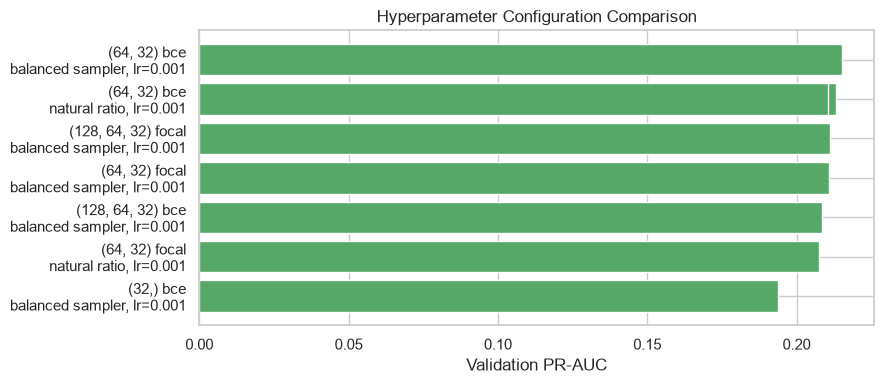

Selected best configuration: {'hidden_sizes': (64, 32), 'dropout': 0.3, 'lr': 0.001, 'loss_type': 'bce', 'balanced': True, 'best_val_pr_auc': 0.2151574379629527, 'pos_weight': nan}


In [25]:
fig, ax = plt.subplots(figsize=(9, 4))
labels = [f"{r['hidden_sizes']} {r['loss_type']}\n"
          f"{'balanced sampler' if r['balanced'] else 'natural ratio'}, lr={r['lr']}"
          for _, r in tuning_df.iterrows()]
ax.barh(labels, tuning_df["best_val_pr_auc"], color="#55A868")
ax.set_xlabel("Validation PR-AUC")
ax.set_title("Hyperparameter Configuration Comparison")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

BEST_CONFIG = tuning_df.iloc[0].to_dict()
print("Selected best configuration:", BEST_CONFIG)

## 11. Final Model Training

Retrain with the best configuration, more epochs, and more patience, then inspect the
learning curves.

In [26]:
final_hidden = BEST_CONFIG["hidden_sizes"]
if not isinstance(final_hidden, tuple):
    final_hidden = tuple(final_hidden)

final_model, final_history, _ = run_training(
    hidden_sizes=final_hidden,
    dropout=BEST_CONFIG["dropout"],
    lr=BEST_CONFIG["lr"],
    loss_type=BEST_CONFIG["loss_type"],
    balanced=bool(BEST_CONFIG["balanced"]),
    pos_weight=BEST_CONFIG.get("pos_weight") if not pd.isna(BEST_CONFIG.get("pos_weight", np.nan)) else None,
    max_epochs=10 if QUICK_TEST else 40,
    patience=4 if QUICK_TEST else 8,
    verbose=True,
)

  epoch   1  train 0.5496  val 0.6034  val PR-AUC 0.2026  val F1 0.1153  (9s)


  epoch   2  train 0.4970  val 0.6029  val PR-AUC 0.2059  val F1 0.1204  (9s)


  epoch   3  train 0.4818  val 0.4497  val PR-AUC 0.1984  val F1 0.1788  (9s)


  epoch   4  train 0.4720  val 0.4554  val PR-AUC 0.2026  val F1 0.1698  (9s)


  epoch   5  train 0.4643  val 0.5379  val PR-AUC 0.1997  val F1 0.1353  (9s)


  epoch   6  train 0.4549  val 0.4770  val PR-AUC 0.2000  val F1 0.1691  (9s)


  epoch   7  train 0.4523  val 0.4866  val PR-AUC 0.1990  val F1 0.1644  (9s)


  epoch   8  train 0.4491  val 0.4995  val PR-AUC 0.2007  val F1 0.1560  (9s)


  epoch   9  train 0.4459  val 0.4725  val PR-AUC 0.1991  val F1 0.1699  (9s)


  epoch  10  train 0.4443  val 0.4932  val PR-AUC 0.1975  val F1 0.1572  (9s)
  early stopping at epoch 10 (no val PR-AUC gain for 8 epochs)


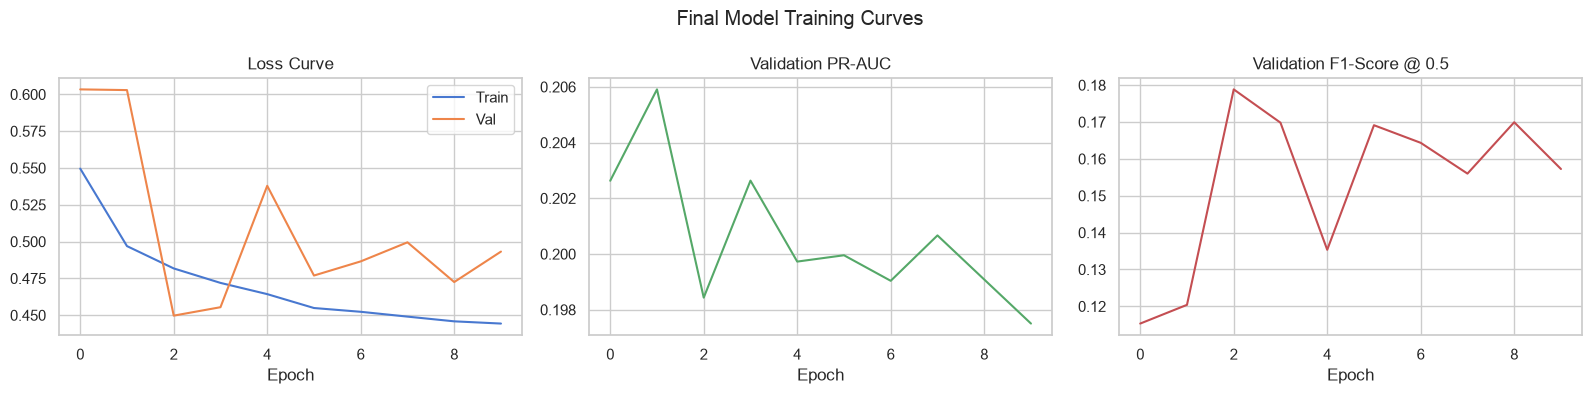

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(final_history["train_loss"], label="Train")
axes[0].plot(final_history["val_loss"], label="Val")
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(final_history["val_pr_auc"], color="#55A868")
axes[1].set_title("Validation PR-AUC")
axes[1].set_xlabel("Epoch")

axes[2].plot(final_history["val_f1"], color="#C44E52")
axes[2].set_title("Validation F1-Score @ 0.5")
axes[2].set_xlabel("Epoch")

plt.suptitle("Final Model Training Curves")
plt.tight_layout()
plt.show()

## 12. Performance Evaluation

In [28]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve,
)

criterion_eval = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([BCE_POS_WEIGHT], device=device))
_, test_pr_auc, _, test_probs, test_targets = evaluate_loader(final_model, test_loader, criterion_eval)

preds_05 = (test_probs > 0.5).astype(int)
roc_auc = roc_auc_score(test_targets, test_probs)
pr_auc = average_precision_score(test_targets, test_probs)

print("=" * 55)
print("  TEST SET @ THRESHOLD = 0.5  (naive baseline, for comparison)")
print("=" * 55)
print(f" ROC-AUC:   {roc_auc:.4f}")
print(f" PR-AUC:    {pr_auc:.4f}")
print(f" Accuracy:  {accuracy_score(test_targets, preds_05):.4f}  <- misleading here, ignore")
print(f" Precision: {precision_score(test_targets, preds_05, zero_division=0):.4f}")
print(f" Recall:    {recall_score(test_targets, preds_05):.4f}")
print(f" F1-Score:  {f1_score(test_targets, preds_05):.4f}")
print()
print(classification_report(test_targets, preds_05, target_names=["Healthy", "At-risk"], zero_division=0))

  TEST SET @ THRESHOLD = 0.5  (naive baseline, for comparison)
 ROC-AUC:   0.7944
 PR-AUC:    0.1768
 Accuracy:  0.7433  <- misleading here, ignore
 Precision: 0.0651
 Recall:    0.7290
 F1-Score:  0.1196

              precision    recall  f1-score   support

     Healthy       0.99      0.74      0.85    550153
     At-risk       0.07      0.73      0.12     13476

    accuracy                           0.74    563629
   macro avg       0.53      0.74      0.48    563629
weighted avg       0.97      0.74      0.83    563629



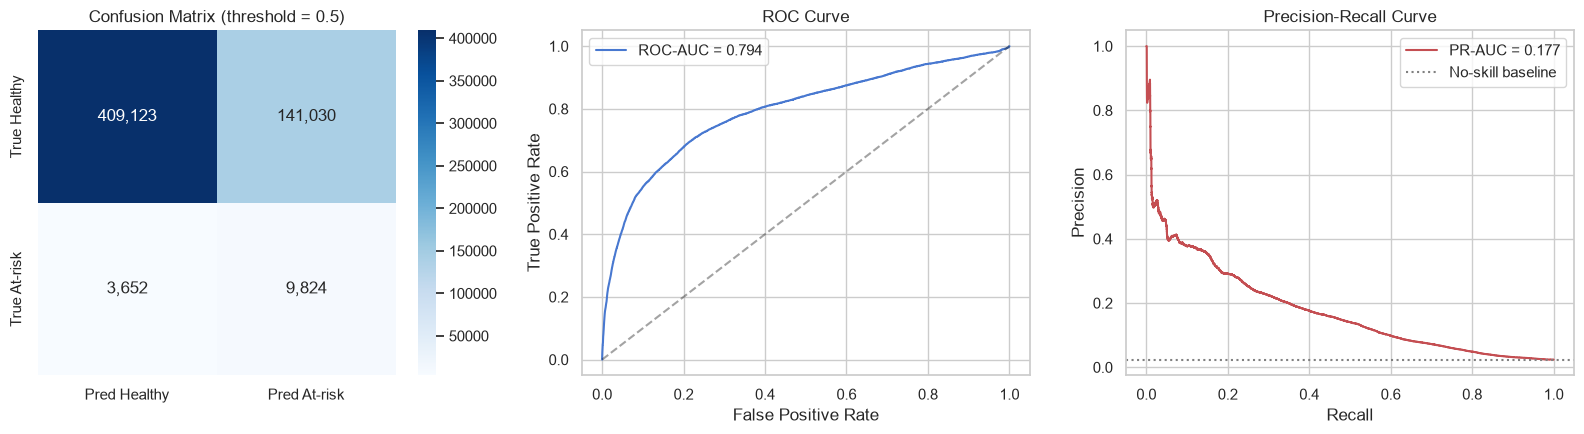

In [29]:
cm_05 = confusion_matrix(test_targets, preds_05)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.heatmap(cm_05, annot=True, fmt=",d", cmap="Blues", ax=axes[0],
            xticklabels=["Pred Healthy", "Pred At-risk"], yticklabels=["True Healthy", "True At-risk"])
axes[0].set_title("Confusion Matrix (threshold = 0.5)")

fpr, tpr, _ = roc_curve(test_targets, test_probs)
axes[1].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

prec_curve, rec_curve, _ = precision_recall_curve(test_targets, test_probs)
axes[2].plot(rec_curve, prec_curve, label=f"PR-AUC = {pr_auc:.3f}", color="#C44E52")
axes[2].axhline(test_targets.mean(), color="grey", linestyle=":", label="No-skill baseline")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")
axes[2].legend()

plt.tight_layout()
plt.show()

## 13. Threshold Tuning (on the VALIDATION set only)

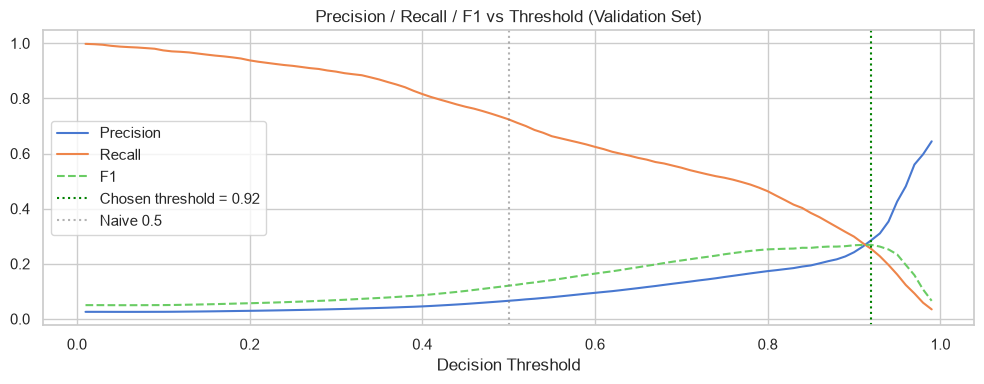

Best threshold by validation F1: 0.92
  -> val precision: 0.2854, val recall: 0.2538, val F1: 0.2687


In [30]:
_, _, _, val_probs, val_targets = evaluate_loader(final_model, val_loader, criterion_eval)

thresholds = np.arange(0.01, 0.991, 0.01)
val_th_results = []
for t in thresholds:
    p_t = (val_probs > t).astype(int)
    val_th_results.append({
        "threshold": t,
        "precision": precision_score(val_targets, p_t, zero_division=0),
        "recall": recall_score(val_targets, p_t, zero_division=0),
        "f1": f1_score(val_targets, p_t, zero_division=0),
    })
val_th_df = pd.DataFrame(val_th_results)
best_row = val_th_df.loc[val_th_df["f1"].idxmax()]
BEST_THRESHOLD = float(best_row["threshold"])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(val_th_df["threshold"], val_th_df["precision"], label="Precision")
ax.plot(val_th_df["threshold"], val_th_df["recall"], label="Recall")
ax.plot(val_th_df["threshold"], val_th_df["f1"], label="F1", linestyle="--")
ax.axvline(BEST_THRESHOLD, color="green", linestyle=":", label=f"Chosen threshold = {BEST_THRESHOLD:.2f}")
ax.axvline(0.5, color="grey", linestyle=":", alpha=0.6, label="Naive 0.5")
ax.set_xlabel("Decision Threshold")
ax.set_title("Precision / Recall / F1 vs Threshold (Validation Set)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best threshold by validation F1: {BEST_THRESHOLD:.2f}")
print(f"  -> val precision: {best_row['precision']:.4f}, val recall: {best_row['recall']:.4f}, "
      f"val F1: {best_row['f1']:.4f}")

  TEST SET @ TUNED THRESHOLD = 0.92  (final, honest numbers)
 ROC-AUC:   0.7944   (threshold-independent, unchanged)
 PR-AUC:    0.1768   (threshold-independent, unchanged)
 Accuracy:  0.9671
 Precision: 0.2750
 Recall:    0.2290
 F1-Score:  0.2499

              precision    recall  f1-score   support

     Healthy       0.98      0.99      0.98    550153
     At-risk       0.27      0.23      0.25     13476

    accuracy                           0.97    563629
   macro avg       0.63      0.61      0.62    563629
weighted avg       0.96      0.97      0.97    563629



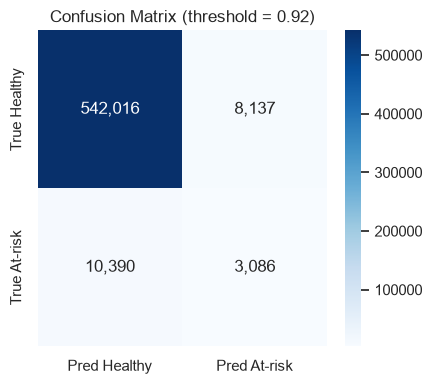

   Metric  Threshold = 0.5 (naive)  Threshold = 0.92 (tuned)
Precision                   0.0651                    0.2750
   Recall                   0.7290                    0.2290
 F1-Score                   0.1196                    0.2499


In [31]:
final_preds = (test_probs > BEST_THRESHOLD).astype(int)
cm_final = confusion_matrix(test_targets, final_preds)

print("=" * 55)
print(f"  TEST SET @ TUNED THRESHOLD = {BEST_THRESHOLD:.2f}  (final, honest numbers)")
print("=" * 55)
print(f" ROC-AUC:   {roc_auc:.4f}   (threshold-independent, unchanged)")
print(f" PR-AUC:    {pr_auc:.4f}   (threshold-independent, unchanged)")
print(f" Accuracy:  {accuracy_score(test_targets, final_preds):.4f}")
print(f" Precision: {precision_score(test_targets, final_preds, zero_division=0):.4f}")
print(f" Recall:    {recall_score(test_targets, final_preds):.4f}")
print(f" F1-Score:  {f1_score(test_targets, final_preds):.4f}")
print()
print(classification_report(test_targets, final_preds, target_names=["Healthy", "At-risk"], zero_division=0))

fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm_final, annot=True, fmt=",d", cmap="Blues", ax=ax,
            xticklabels=["Pred Healthy", "Pred At-risk"], yticklabels=["True Healthy", "True At-risk"])
ax.set_title(f"Confusion Matrix (threshold = {BEST_THRESHOLD:.2f})")
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-Score"],
    "Threshold = 0.5 (naive)": [
        precision_score(test_targets, preds_05, zero_division=0),
        recall_score(test_targets, preds_05),
        f1_score(test_targets, preds_05),
    ],
    f"Threshold = {BEST_THRESHOLD:.2f} (tuned)": [
        precision_score(test_targets, final_preds, zero_division=0),
        recall_score(test_targets, final_preds),
        f1_score(test_targets, final_preds),
    ],
}).round(4)
print(comparison.to_string(index=False))

## 14. Business-Relevant Evaluation: Precision@K / Lift

top_%_flagged  n_flagged  precision_at_k  recall_at_k
         0.1%        563          0.5027       0.0210
         0.5%       2818          0.3896       0.0815
         1.0%       5636          0.3554       0.1486
         2.0%      11272          0.2741       0.2293
         5.0%      28181          0.1832       0.3831
        10.0%      56362          0.1271       0.5315

Overall base rate (random-flagging precision): 2.3909%


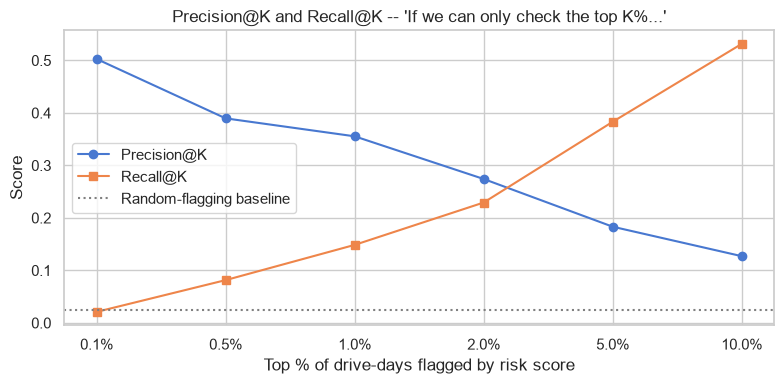

In [32]:
order = np.argsort(-test_probs)
sorted_targets = test_targets[order]
n = len(sorted_targets)

k_fractions = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10]
rows = []
for k in k_fractions:
    k_n = max(int(n * k), 1)
    flagged = sorted_targets[:k_n]
    rows.append({"top_%_flagged": f"{k*100:.1f}%", "n_flagged": k_n,
                 "precision_at_k": round(flagged.mean(), 4),
                 "recall_at_k": round(flagged.sum() / max(sorted_targets.sum(), 1), 4)})

precision_at_k_df = pd.DataFrame(rows)
print(precision_at_k_df.to_string(index=False))
print(f"\nOverall base rate (random-flagging precision): {test_targets.mean():.4%}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(precision_at_k_df["top_%_flagged"], precision_at_k_df["precision_at_k"], marker="o", label="Precision@K")
ax.plot(precision_at_k_df["top_%_flagged"], precision_at_k_df["recall_at_k"], marker="s", label="Recall@K")
ax.axhline(test_targets.mean(), color="grey", linestyle=":", label="Random-flagging baseline")
ax.set_xlabel("Top % of drive-days flagged by risk score")
ax.set_ylabel("Score")
ax.set_title("Precision@K and Recall@K -- 'If we can only check the top K%...'")
ax.legend()
plt.tight_layout()
plt.show()

## 15. Prediction Demo

A quick illustration of what an individual prediction looks like, using the tuned
threshold from Section 13.

In [33]:
rng = np.random.RandomState(RANDOM_STATE)
demo_indices = rng.choice(len(test_dataset), size=min(8, len(test_dataset)), replace=False)
final_model.eval()
with torch.no_grad():
    demo_X = torch.stack([test_dataset[i][0] for i in demo_indices]).to(device)
    demo_y = torch.stack([test_dataset[i][1] for i in demo_indices]).cpu().numpy().flatten()
    demo_probs = torch.sigmoid(final_model(demo_X)).cpu().numpy().flatten()

demo_preds = (demo_probs > BEST_THRESHOLD).astype(int)
demo_meta = test_meta.iloc[demo_indices]
demo_result = pd.DataFrame({
    "drive": demo_meta["id"].values,
    "model": [m.replace("TOSHIBA ", "") for m in demo_meta["model"].values],
    "date": demo_meta["time"].dt.date.values,
    "True label": ["At-risk" if t else "Healthy" for t in demo_y.astype(int)],
    "Failure probability": [f"{p:.4f}" for p in demo_probs],
    f"Predicted (thr={BEST_THRESHOLD:.2f})": ["At-risk" if p else "Healthy" for p in demo_preds],
    "Correct?": ["Yes" if a == b else "No" for a, b in zip(demo_y.astype(int), demo_preds)],
})
demo_result

,drive,model,date,True label,Failure probability,Predicted (thr=0.92),Correct?
0,8160A20BFVKG,MG08ACA16TA,2025-12-28,Healthy,0.5756,Healthy,Yes
1,71B0A13BFV8G,MG08ACA16TEY,2025-01-15,Healthy,0.2887,Healthy,Yes
2,Z2C0A003FVKG,MG08ACA16TA,2024-11-19,Healthy,0.3862,Healthy,Yes
3,40X0A09FF97G,MG07ACA14TA,2024-11-11,Healthy,0.5673,Healthy,Yes
4,22D0A18CFV8G,MG08ACA16TEY,2025-10-30,Healthy,0.8260,Healthy,Yes
5,33Q0A0E3FVKG,MG08ACA16TA,2024-11-22,Healthy,0.5631,Healthy,Yes
6,92L0A1ASFVKG,MG08ACA16TA,2025-08-27,Healthy,0.3238,Healthy,Yes
7,10K0A0RZF97G,MG07ACA14TA,2024-06-12,Healthy,0.3616,Healthy,Yes


## 16. Saving the Model & Preprocessing Config

Save the classifier weights and a JSON config with everything needed to reproduce
inference: feature list, scaler/imputer parameters, architecture, chosen threshold,
and the 90-day window definition.

In [34]:
import json

torch.save(final_model.state_dict(), f"{MODELS_DIR}/toshiba_drive_failure_dnn.pth")

best_hidden = list(final_hidden)
preprocessing_config = {
    "dataset": "Toshiba export (toshiba_drivestats.parquet)",
    "feature_columns": FEATURE_COLUMNS,
    "attr_feature_columns": ATTR_FEATURE_COLUMNS,
    "model_feature_columns": MODEL_FEATURE_COLUMNS,
    "base_attributes": ATTRS,
    "core_attributes": CORE_ATTRS,
    "extended_attributes": EXTENDED_ATTRS,
    "input_window_days": INPUT_WINDOW_DAYS,
    "delta_lags": list(DELTA_LAGS),
    "window_span_tolerance_days": MIN_WINDOW_SPAN_TOLERANCE,
    "failure_horizon_days": FAILURE_HORIZON_DAYS,
    "best_config": {
        "hidden_sizes": best_hidden,
        "dropout": float(BEST_CONFIG["dropout"]),
        "lr": float(BEST_CONFIG["lr"]),
        "loss_type": BEST_CONFIG["loss_type"],
        "balanced_sampler": bool(BEST_CONFIG["balanced"]),
    },
    "pos_weight": float(POS_WEIGHT),
    "decision_threshold": BEST_THRESHOLD,
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "imputer_statistics": imputer.statistics_.tolist(),
    "test_metrics": {
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "precision": float(precision_score(test_targets, final_preds, zero_division=0)),
        "recall": float(recall_score(test_targets, final_preds)),
        "f1": float(f1_score(test_targets, final_preds)),
    },
}

with open(f"{MODELS_DIR}/toshiba_preprocessing_config.json", "w") as f:
    json.dump(preprocessing_config, f, indent=2)

print(f"Saved: {MODELS_DIR}/toshiba_drive_failure_dnn.pth")
print(f"Saved: {MODELS_DIR}/toshiba_preprocessing_config.json")

Saved: toshiba_drive_failure_dnn.pth
Saved: toshiba_preprocessing_config.json


## 16b. Alternative Model: XGBoost Classifier

Same features, same splits, same metrics as the DNN above — the only thing that changes
is the learner, so the comparison in the table below is apples-to-apples.

One parameter gets swept rather than set to its obvious default. `scale_pos_weight`
is conventionally set to the negative/positive ratio (~37 here), and doing that makes
validation PR-AUC peak after about a dozen trees and then decline, so early stopping
returns a barely-trained model. PR-AUC scores only the **ranking** of the drives, and
up-weighting the positives distorts the gradient without improving that ranking. This
is the same over-correction the DNN ran into in Section 6, arriving through a different
door — so it is measured here instead of assumed.

In [35]:
from xgboost import XGBClassifier

# Train on the GPU when there is one; predict back on the CPU, because the feature
# tables are NumPy arrays in host memory and a GPU booster would only copy them over.
XGB_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Reuse the exact same imputed features / target / splits as the DNN classifier
# (X_train_imp, X_val_imp, X_test_imp, y_train, y_val, y_test come from Section 5).
# No scaling needed -- tree-based models are invariant to monotonic feature scaling.
#
# scale_pos_weight is swept rather than set to POS_WEIGHT, which is the obvious-looking
# default and is wrong here. At the full 37x weight the validation PR-AUC peaks after
# roughly a dozen trees and then falls, so early stopping hands back a barely-trained
# model. PR-AUC only cares about the RANKING of the scores, and up-weighting the
# positives distorts the gradient without improving that ranking -- the same
# over-correction the DNN hit in Section 6.

XGB_GRID = [
    {"scale_pos_weight": 1.0,        "learning_rate": 0.02, "max_depth": 6},
    {"scale_pos_weight": 1.0,        "learning_rate": 0.05, "max_depth": 6},
    {"scale_pos_weight": np.sqrt(POS_WEIGHT), "learning_rate": 0.02, "max_depth": 6},
    {"scale_pos_weight": POS_WEIGHT, "learning_rate": 0.05, "max_depth": 6},
    {"scale_pos_weight": 1.0,        "learning_rate": 0.02, "max_depth": 8},
]

xgb_results = []
for i, params in enumerate(XGB_GRID, start=1):
    t0 = time.time()
    clf = XGBClassifier(
        n_estimators=300 if QUICK_TEST else 2000,
        subsample=0.8, colsample_bytree=0.8, eval_metric="aucpr",
        early_stopping_rounds=50, random_state=RANDOM_STATE, n_jobs=-1,
        tree_method="hist", device=XGB_DEVICE, **params,
    )
    clf.fit(X_train_imp, y_train, eval_set=[(X_val_imp, y_val)], verbose=False)
    clf.set_params(device="cpu")
    val_pr = average_precision_score(y_val, clf.predict_proba(X_val_imp)[:, 1])
    xgb_results.append({**params, "best_iteration": clf.best_iteration,
                        "val_pr_auc": val_pr, "model": clf})
    print(f"  [{i}/{len(XGB_GRID)}] spw={params['scale_pos_weight']:5.1f} "
          f"lr={params['learning_rate']} depth={params['max_depth']} -> "
          f"{clf.best_iteration:4d} trees, val PR-AUC {val_pr:.4f}  ({time.time() - t0:.0f}s)")

xgb_tuning_df = pd.DataFrame([{k: v for k, v in r.items() if k != "model"}
                              for r in xgb_results]).sort_values("val_pr_auc", ascending=False)
print("\n" + xgb_tuning_df.to_string(index=False))

best_xgb = max(xgb_results, key=lambda r: r["val_pr_auc"])
xgb_clf = best_xgb["model"]
print(f"\nSelected: scale_pos_weight={best_xgb['scale_pos_weight']:.1f}, "
      f"lr={best_xgb['learning_rate']}, depth={best_xgb['max_depth']}, "
      f"{xgb_clf.best_iteration} trees")

  [1/5] spw=  1.0 lr=0.02 depth=6 ->  291 trees, val PR-AUC 0.2502  (32s)


  [2/5] spw=  1.0 lr=0.05 depth=6 ->   65 trees, val PR-AUC 0.2444  (12s)


  [3/5] spw=  6.1 lr=0.02 depth=6 ->  289 trees, val PR-AUC 0.2583  (32s)


  [4/5] spw= 37.4 lr=0.05 depth=6 ->   12 trees, val PR-AUC 0.2364  (7s)


  [5/5] spw=  1.0 lr=0.02 depth=8 ->  142 trees, val PR-AUC 0.2435  (23s)

 scale_pos_weight  learning_rate  max_depth  best_iteration  val_pr_auc
         6.118712           0.02          6             289    0.258254
         1.000000           0.02          6             291    0.250249
         1.000000           0.05          6              65    0.244435
         1.000000           0.02          8             142    0.243486
        37.438632           0.05          6              12    0.236411

Selected: scale_pos_weight=6.1, lr=0.02, depth=6, 289 trees


In [36]:
# Threshold tuning on the VALIDATION set only -- identical protocol to Section 13
xgb_val_probs = xgb_clf.predict_proba(X_val_imp)[:, 1]
xgb_test_probs = xgb_clf.predict_proba(X_test_imp)[:, 1]

xgb_val_th_results = []
for t in np.arange(0.01, 0.991, 0.01):
    p_t = (xgb_val_probs > t).astype(int)
    xgb_val_th_results.append({
        "threshold": t,
        "precision": precision_score(y_val, p_t, zero_division=0),
        "recall": recall_score(y_val, p_t, zero_division=0),
        "f1": f1_score(y_val, p_t, zero_division=0),
    })
xgb_val_th_df = pd.DataFrame(xgb_val_th_results)
xgb_best_row = xgb_val_th_df.loc[xgb_val_th_df["f1"].idxmax()]
XGB_BEST_THRESHOLD = float(xgb_best_row["threshold"])

print(f"XGBoost best threshold by validation F1: {XGB_BEST_THRESHOLD:.2f}")
print(f"  -> val precision: {xgb_best_row['precision']:.4f}, val recall: {xgb_best_row['recall']:.4f}, "
      f"val F1: {xgb_best_row['f1']:.4f}")

XGBoost best threshold by validation F1: 0.58
  -> val precision: 0.3154, val recall: 0.3161, val F1: 0.3157


  XGBOOST -- TEST SET @ TUNED THRESHOLD = 0.58
 ROC-AUC:   0.8304
 PR-AUC:    0.2353
 Accuracy:  0.9662
 Precision: 0.2970
 Recall:    0.3036
 F1-Score:  0.3002



              precision    recall  f1-score   support

     Healthy       0.98      0.98      0.98    550153
     At-risk       0.30      0.30      0.30     13476

    accuracy                           0.97    563629
   macro avg       0.64      0.64      0.64    563629
weighted avg       0.97      0.97      0.97    563629



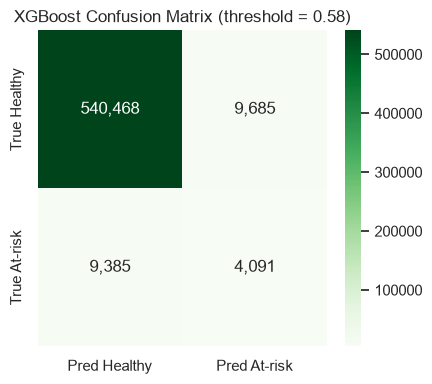

In [37]:
xgb_roc_auc = roc_auc_score(y_test, xgb_test_probs)
xgb_pr_auc = average_precision_score(y_test, xgb_test_probs)
xgb_final_preds = (xgb_test_probs > XGB_BEST_THRESHOLD).astype(int)

print("=" * 55)
print(f"  XGBOOST -- TEST SET @ TUNED THRESHOLD = {XGB_BEST_THRESHOLD:.2f}")
print("=" * 55)
print(f" ROC-AUC:   {xgb_roc_auc:.4f}")
print(f" PR-AUC:    {xgb_pr_auc:.4f}")
print(f" Accuracy:  {accuracy_score(y_test, xgb_final_preds):.4f}")
print(f" Precision: {precision_score(y_test, xgb_final_preds, zero_division=0):.4f}")
print(f" Recall:    {recall_score(y_test, xgb_final_preds):.4f}")
print(f" F1-Score:  {f1_score(y_test, xgb_final_preds):.4f}")
print()
print(classification_report(y_test, xgb_final_preds, target_names=["Healthy", "At-risk"], zero_division=0))

xgb_cm = confusion_matrix(y_test, xgb_final_preds)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(xgb_cm, annot=True, fmt=",d", cmap="Greens", ax=ax,
            xticklabels=["Pred Healthy", "Pred At-risk"], yticklabels=["True Healthy", "True At-risk"])
ax.set_title(f"XGBoost Confusion Matrix (threshold = {XGB_BEST_THRESHOLD:.2f})")
plt.tight_layout()
plt.show()

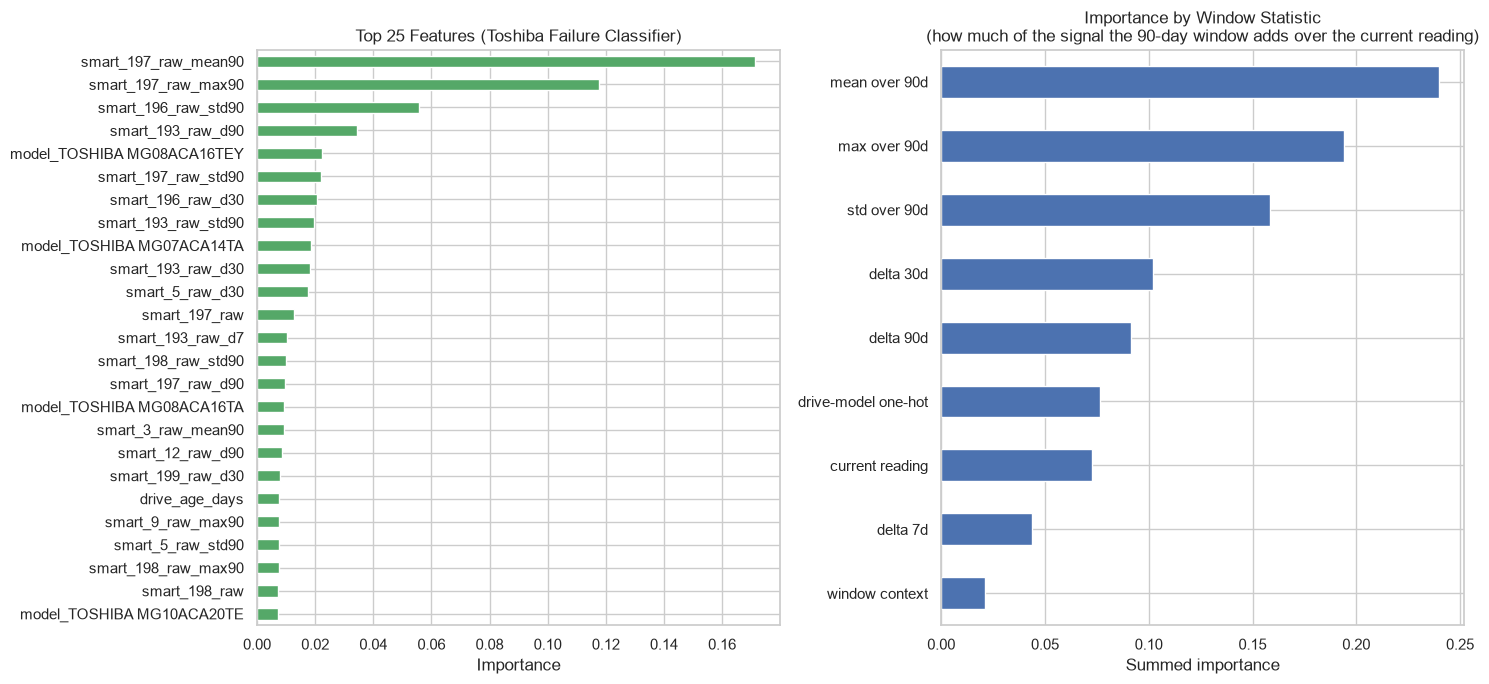

Share of total importance by window statistic:
mean over 90d          24.0
max over 90d           19.4
std over 90d           15.8
delta 30d              10.2
delta 90d               9.1
drive-model one-hot     7.7
current reading         7.3
delta 7d                4.4
window context          2.1


In [38]:
# Feature importance -- a natural bonus XGBoost gives "for free" vs. the DNN.
# Grouped two ways: the single most useful columns, and which window statistic
# earns its keep, which is the direct evidence on whether 90 days of input pays off.
importances = pd.Series(xgb_clf.feature_importances_, index=FEATURE_COLUMNS)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
importances.sort_values(ascending=False).head(25).plot(kind="barh", ax=axes[0], color="#55A868")
axes[0].invert_yaxis()
axes[0].set_title("Top 25 Features (Toshiba Failure Classifier)")
axes[0].set_xlabel("Importance")


def window_stat_of(col):
    if col.startswith("model_"):
        return "drive-model one-hot"
    if col in ("window_span_days", "drive_age_days", "capacity_tb"):
        return "window context"
    for lag in DELTA_LAGS:
        if col.endswith(f"_d{lag}"):
            return f"delta {lag}d"
    for stat in ("mean", "std", "max"):
        if col.endswith(f"_{stat}{INPUT_WINDOW_DAYS}"):
            return f"{stat} over {INPUT_WINDOW_DAYS}d"
    return "current reading"


by_stat = importances.groupby(importances.index.map(window_stat_of)).sum().sort_values()
by_stat.plot(kind="barh", ax=axes[1], color="#4C72B0")
axes[1].set_title(f"Importance by Window Statistic\n(how much of the signal the "
                  f"{INPUT_WINDOW_DAYS}-day window adds over the current reading)")
axes[1].set_xlabel("Summed importance")
plt.tight_layout()
plt.show()

print("Share of total importance by window statistic:")
print((100 * by_stat / by_stat.sum()).round(1).sort_values(ascending=False).to_string())

In [39]:
# Direct comparison: DNN vs. XGBoost, same test set, same metrics
clf_comparison_df = pd.DataFrame({
    "Metric": ["ROC-AUC", "PR-AUC", "Precision", "Recall", "F1-Score"],
    "DNN (Section 12-13)": [roc_auc, pr_auc,
                            precision_score(test_targets, final_preds, zero_division=0),
                            recall_score(test_targets, final_preds),
                            f1_score(test_targets, final_preds)],
    "XGBoost": [xgb_roc_auc, xgb_pr_auc,
                precision_score(y_test, xgb_final_preds, zero_division=0),
                recall_score(y_test, xgb_final_preds),
                f1_score(y_test, xgb_final_preds)],
}).round(4)
clf_comparison_df["Winner"] = np.where(
    clf_comparison_df["XGBoost"] > clf_comparison_df["DNN (Section 12-13)"], "XGBoost",
    np.where(clf_comparison_df["XGBoost"] < clf_comparison_df["DNN (Section 12-13)"], "DNN", "Tie")
)
print(clf_comparison_df.to_string(index=False))

xgb_clf.save_model(f"{MODELS_DIR}/toshiba_drive_failure_xgb.json")
print(f"\nSaved: {MODELS_DIR}/toshiba_drive_failure_xgb.json")

   Metric  DNN (Section 12-13)  XGBoost  Winner
  ROC-AUC               0.7944   0.8304 XGBoost
   PR-AUC               0.1768   0.2353 XGBoost
Precision               0.2750   0.2970 XGBoost
   Recall               0.2290   0.3036 XGBoost
 F1-Score               0.2499   0.3002 XGBoost

Saved: toshiba_drive_failure_xgb.json


## 16c. Across the 14 Drive Models

Everything above pools all 14 Toshiba families into one model. That is a choice, and
this section tests it three ways:

1. **Per-family breakdown** — does the pooled model serve every family, or is the
   headline number carried by the two large families that supply two thirds of the rows?
2. **Pooled vs. per-family** — would a family be better served by a model trained on
   nothing but its own drives?
3. **Leave-one-model-out** — how well does the pooled model transfer to a family it has
   never seen, which is what happens the day a new drive model enters the fleet.

Families with no failures in the export (`MD04ABA400V`, `HDWE160`, `MG11ACA16TE`) have no
positives to score, so they appear in the row counts and are skipped in the metrics.

In [40]:
# Per-family breakdown of the pooled models on the shared test set.
test_model_col = test_meta["model"].to_numpy()
y_test_np = y_test.to_numpy()

per_model_rows = []
for model_name in sorted(test_meta["model"].unique()):
    mask = test_model_col == model_name
    y_m = y_test_np[mask]
    row = {
        "model": model_name.replace("TOSHIBA ", ""),
        "test_rows": int(mask.sum()),
        "drives": test_meta.loc[mask, "id"].nunique(),
        "positives": int(y_m.sum()),
    }
    if y_m.sum() > 0 and y_m.sum() < len(y_m):
        row["DNN_PR_AUC"] = average_precision_score(y_m, test_probs[mask])
        row["XGB_PR_AUC"] = average_precision_score(y_m, xgb_test_probs[mask])
        row["DNN_ROC_AUC"] = roc_auc_score(y_m, test_probs[mask])
        row["XGB_ROC_AUC"] = roc_auc_score(y_m, xgb_test_probs[mask])
        row["XGB_recall"] = recall_score(y_m, (xgb_test_probs[mask] > XGB_BEST_THRESHOLD).astype(int))
        row["XGB_precision"] = precision_score(y_m, (xgb_test_probs[mask] > XGB_BEST_THRESHOLD).astype(int),
                                               zero_division=0)
    per_model_rows.append(row)

per_model_df = pd.DataFrame(per_model_rows).sort_values("test_rows", ascending=False).reset_index(drop=True)
print("Pooled model, broken down by drive family (test set):")
print(per_model_df.round(4).to_string(index=False))

Pooled model, broken down by drive family (test set):
       model  test_rows  drives  positives  DNN_PR_AUC  XGB_PR_AUC  DNN_ROC_AUC  XGB_ROC_AUC  XGB_recall  XGB_precision
 MG07ACA14TA     202108     356       4548      0.2095      0.2836       0.7862       0.8380      0.4281         0.2951
 MG08ACA16TA     196039     360       4799      0.1656      0.2177       0.7900       0.8066      0.3003         0.2923
MG08ACA16TEY     101673     170       2367      0.1333      0.1740       0.8049       0.8378      0.0917         0.3741
 MG08ACA16TE      28824      56        762      0.1376      0.1232       0.7588       0.7554      0.1601         0.1519
 MG10ACA20TE      13624      45        559      0.3135      0.4254       0.9254       0.8976      0.4758         0.4532
 MQ01ABF050M       7969      16        155      0.1050      0.1337       0.7244       0.6648      0.2000         0.2818
MG07ACA14TEY       7792      14         62      0.0353      0.1356       0.8479       0.9585      0.0161  

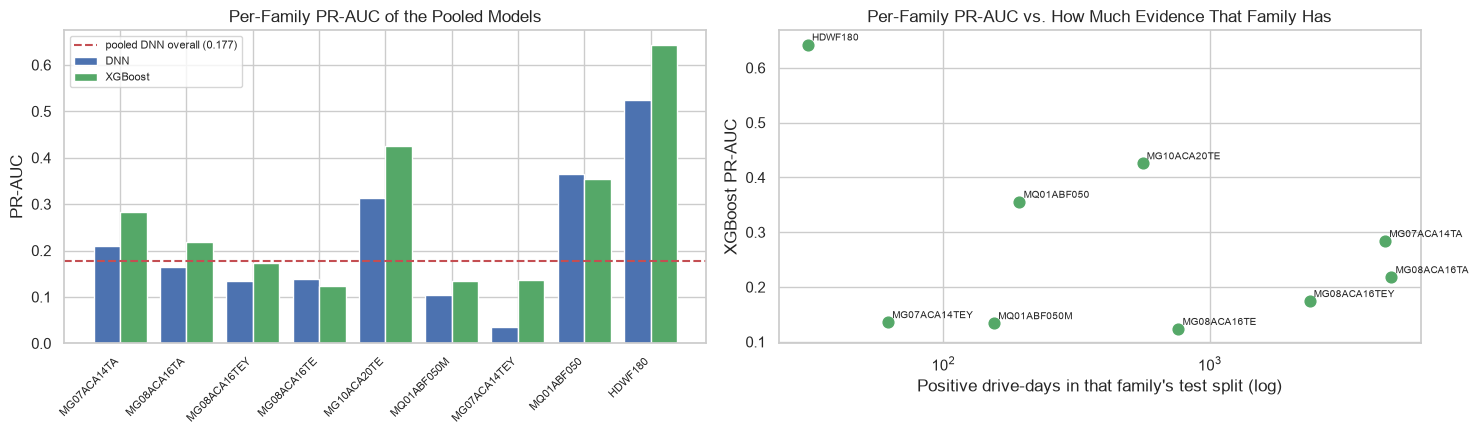

In [41]:
scored = per_model_df.dropna(subset=["XGB_PR_AUC"]).sort_values("test_rows", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

x = np.arange(len(scored))
axes[0].bar(x - 0.2, scored["DNN_PR_AUC"], 0.4, label="DNN", color="#4C72B0")
axes[0].bar(x + 0.2, scored["XGB_PR_AUC"], 0.4, label="XGBoost", color="#55A868")
axes[0].axhline(pr_auc, color="#C44E52", linestyle="--", label=f"pooled DNN overall ({pr_auc:.3f})")
axes[0].set_xticks(x)
axes[0].set_xticklabels(scored["model"], rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("PR-AUC")
axes[0].set_title("Per-Family PR-AUC of the Pooled Models")
axes[0].legend(fontsize=8)

axes[1].scatter(scored["positives"], scored["XGB_PR_AUC"], s=60, color="#55A868")
for _, r in scored.iterrows():
    axes[1].annotate(r["model"], (r["positives"], r["XGB_PR_AUC"]), fontsize=7,
                     xytext=(3, 3), textcoords="offset points")
axes[1].set_xscale("log")
axes[1].set_xlabel("Positive drive-days in that family's test split (log)")
axes[1].set_ylabel("XGBoost PR-AUC")
axes[1].set_title("Per-Family PR-AUC vs. How Much Evidence That Family Has")
plt.tight_layout()
plt.show()

In [42]:
# Pooled vs. per-family, and leave-one-model-out transfer.
# Uses a float32 view of the whole feature matrix: 2.7M x N in float64 would be copied
# twice per experiment, and tree split points do not need the extra precision.
import warnings

XGB_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

X_all_np = X_all.to_numpy(dtype=np.float32)
y_all_np = y_all.to_numpy()
model_col = meta_all["model"].to_numpy()
id_col = meta_all["id"].to_numpy()

test_id_set = set(test_meta["id"])
is_test_row = np.fromiter((i in test_id_set for i in id_col), dtype=bool, count=len(id_col))

CROSS_MODEL_MIN_POSITIVES = 200 if QUICK_TEST else 2000   # a family needs enough positives for its own model
cross_candidates = [
    m for m in meta_all["model"].unique()
    if int(y_all_np[(model_col == m)].sum()) >= CROSS_MODEL_MIN_POSITIVES
]
print(f"Families with at least {CROSS_MODEL_MIN_POSITIVES:,} positive drive-days: "
      f"{[m.replace('TOSHIBA ', '') for m in cross_candidates]}")


def quick_xgb(train_mask, eval_mask=None):
    """A pooled-settings XGBoost, deliberately without early stopping so that every
    cell of the comparison table below is fit under identical conditions."""
    clf = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, eval_metric="aucpr", random_state=RANDOM_STATE,
        n_jobs=-1, tree_method="hist", device=XGB_DEVICE,
        scale_pos_weight=1.0,   # per the Section 16b sweep: reweighting hurts the ranking
    )
    # A column can be entirely NaN in one family's training rows (EXTENDED_ATTRS are not
    # reported by the "EY" families), and nanmedian warns and returns NaN for it. Any fill
    # is arbitrary for a column with no observed values, so 0.0 it is.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        med = np.nan_to_num(np.nanmedian(X_all_np[train_mask], axis=0), nan=0.0)
    Xtr = np.where(np.isnan(X_all_np[train_mask]), med, X_all_np[train_mask])
    clf.fit(Xtr, y_all_np[train_mask], verbose=False)
    clf.set_params(device="cpu")
    return clf, med

Families with at least 2,000 positive drive-days: ['MG07ACA14TA', 'MG08ACA16TEY', 'MG08ACA16TA', 'MG08ACA16TE', 'MG10ACA20TE']


In [43]:
cross_rows = []
for m in cross_candidates:
    fam = (model_col == m)
    fam_test = fam & is_test_row
    fam_train = fam & ~is_test_row
    y_fam_test = y_all_np[fam_test]
    if y_fam_test.sum() == 0:
        continue

    # (a) pooled model, already trained on every family
    pooled_pr = average_precision_score(y_fam_test, xgb_test_probs[test_model_col == m])

    # (b) trained on this family alone
    own, own_med = quick_xgb(fam_train)
    Xte = np.where(np.isnan(X_all_np[fam_test]), own_med, X_all_np[fam_test])
    own_pr = average_precision_score(y_fam_test, own.predict_proba(Xte)[:, 1])

    # (c) trained on every OTHER family -- this family is unseen
    other_train = (~fam) & ~is_test_row
    lomo, lomo_med = quick_xgb(other_train)
    Xte2 = np.where(np.isnan(X_all_np[fam_test]), lomo_med, X_all_np[fam_test])
    lomo_pr = average_precision_score(y_fam_test, lomo.predict_proba(Xte2)[:, 1])

    cross_rows.append({
        "model": m.replace("TOSHIBA ", ""),
        "test_rows": int(fam_test.sum()),
        "test_positives": int(y_fam_test.sum()),
        "pooled_PR_AUC": pooled_pr,
        "family_only_PR_AUC": own_pr,
        "leave_one_out_PR_AUC": lomo_pr,
    })
    print(f"  {m.replace('TOSHIBA ', ''):16s} pooled {pooled_pr:.4f} | "
          f"family-only {own_pr:.4f} | never-seen {lomo_pr:.4f}")

cross_df = pd.DataFrame(cross_rows)
cross_df["pooled_vs_family_only"] = (cross_df["pooled_PR_AUC"] - cross_df["family_only_PR_AUC"]).round(4)
cross_df["transfer_gap"] = (cross_df["pooled_PR_AUC"] - cross_df["leave_one_out_PR_AUC"]).round(4)
print("\n" + cross_df.round(4).to_string(index=False))

  MG07ACA14TA      pooled 0.2836 | family-only 0.2734 | never-seen 0.1284


  MG08ACA16TEY     pooled 0.1740 | family-only 0.1636 | never-seen 0.0941


  MG08ACA16TA      pooled 0.2177 | family-only 0.1943 | never-seen 0.1496


  MG08ACA16TE      pooled 0.1232 | family-only 0.1257 | never-seen 0.1187


  MG10ACA20TE      pooled 0.4254 | family-only 0.3103 | never-seen 0.3025

       model  test_rows  test_positives  pooled_PR_AUC  family_only_PR_AUC  leave_one_out_PR_AUC  pooled_vs_family_only  transfer_gap
 MG07ACA14TA     202108            4548         0.2836              0.2734                0.1284                 0.0102        0.1552
MG08ACA16TEY     101673            2367         0.1740              0.1636                0.0941                 0.0105        0.0799
 MG08ACA16TA     196039            4799         0.2177              0.1943                0.1496                 0.0234        0.0680
 MG08ACA16TE      28824             762         0.1232              0.1257                0.1187                -0.0025        0.0045
 MG10ACA20TE      13624             559         0.4254              0.3103                0.3025                 0.1151        0.1230


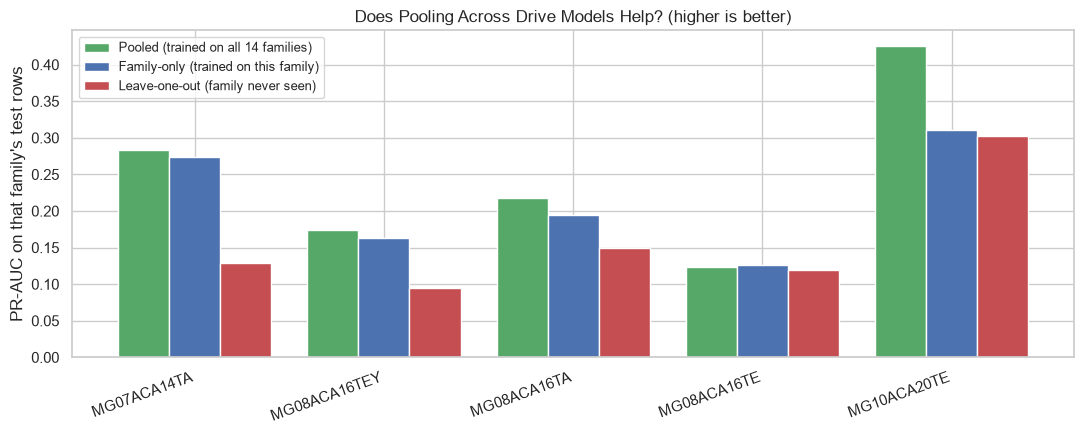

Reading this chart:
  pooled > family-only  -> the other families contribute usable signal; pool them.
  pooled > leave-one-out -> a family the model has never seen is scored worse,
                            i.e. a newly introduced drive model needs its own data
                            before the pooled model can be trusted on it.


In [44]:
if cross_df.empty:
    print(f"No family reached {CROSS_MODEL_MIN_POSITIVES:,} positive drive-days -- "
          f"nothing to compare (only expected under QUICK_TEST).")
else:
    fig, ax = plt.subplots(figsize=(11, 4.5))
    x = np.arange(len(cross_df))
    ax.bar(x - 0.27, cross_df["pooled_PR_AUC"], 0.27,
           label="Pooled (trained on all 14 families)", color="#55A868")
    ax.bar(x, cross_df["family_only_PR_AUC"], 0.27,
           label="Family-only (trained on this family)", color="#4C72B0")
    ax.bar(x + 0.27, cross_df["leave_one_out_PR_AUC"], 0.27,
           label="Leave-one-out (family never seen)", color="#C44E52")
    ax.set_xticks(x)
    ax.set_xticklabels(cross_df["model"], rotation=20, ha="right")
    ax.set_ylabel("PR-AUC on that family's test rows")
    ax.set_title("Does Pooling Across Drive Models Help? (higher is better)")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

print("Reading this chart:")
print("  pooled > family-only  -> the other families contribute usable signal; pool them.")
print("  pooled > leave-one-out -> a family the model has never seen is scored worse,")
print("                            i.e. a newly introduced drive model needs its own data")
print("                            before the pooled model can be trusted on it.")

In [45]:
del X_all_np
cross_df.to_csv(f"{RESULTS_DIR}/toshiba_cross_model_comparison.csv", index=False)
per_model_df.to_csv(f"{RESULTS_DIR}/toshiba_per_model_metrics.csv", index=False)
print(f"Saved: {RESULTS_DIR}/toshiba_cross_model_comparison.csv, {RESULTS_DIR}/toshiba_per_model_metrics.csv")

Saved: toshiba_cross_model_comparison.csv, toshiba_per_model_metrics.csv


---
# Part 2: Remaining Useful Life (RUL) Regression

A separate regression model estimates **exactly how many days** remain until failure —
useful for prioritising maintenance among the drives already flagged as at-risk. Same
90-day input window, same leakage-free grouping, restricted to drives that actually
failed and to rows within `RUL_HORIZON_DAYS` of the failure.

In [46]:
rul_mask = full_window.values & df_feat["days_to_failure"].between(0, RUL_HORIZON_DAYS).fillna(False).values
rul_positions = np.flatnonzero(rul_mask[full_window.values])   # positions inside X_all / meta_all

X_rul_all = X_all.iloc[rul_positions].reset_index(drop=True)
rul_meta = meta_all.iloc[rul_positions].reset_index(drop=True)
y_rul_all = rul_meta["days_to_failure"].astype(np.float32)

print(f"RUL dataset: {len(X_rul_all):,} rows from {rul_meta['id'].nunique():,} failed drives")
print(f"RUL target range: 0 to {RUL_HORIZON_DAYS} days, mean = {y_rul_all.mean():.1f} days")
print(f"Families represented: {rul_meta['model'].nunique()}")

RUL dataset: 136,102 rows from 2,374 failed drives
RUL target range: 0 to 60 days, mean = 29.8 days
Families represented: 11


In [47]:
rul_gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
rul_tv_idx, rul_test_idx = next(rul_gss.split(X_rul_all, groups=rul_meta["id"]))
rul_gss2 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
rul_tr_i, rul_val_i = next(rul_gss2.split(X_rul_all.iloc[rul_tv_idx], groups=rul_meta.iloc[rul_tv_idx]["id"]))
rul_train_idx, rul_val_idx = np.sort(rul_tv_idx[rul_tr_i]), np.sort(rul_tv_idx[rul_val_i])
rul_test_idx = np.sort(rul_test_idx)

for name, idx in [("RUL Train", rul_train_idx), ("RUL Val", rul_val_idx), ("RUL Test", rul_test_idx)]:
    print(f"{name:10s}: {len(idx):>8,} rows, {rul_meta.iloc[idx]['id'].nunique():>5,} drives")

assert set(rul_meta.iloc[rul_train_idx]["id"]) & set(rul_meta.iloc[rul_test_idx]["id"]) == set()
print("\nNo failed drive appears in more than one RUL split.")

RUL Train :   92,523 rows, 1,614 drives
RUL Val   :   16,438 rows,   285 drives
RUL Test  :   27,141 rows,   475 drives

No failed drive appears in more than one RUL split.


In [48]:
rul_imputer = SimpleImputer(strategy="median")
rul_scaler = StandardScaler()

X_rul_train_imp = rul_imputer.fit_transform(X_rul_all.iloc[rul_train_idx])
X_rul_val_imp = rul_imputer.transform(X_rul_all.iloc[rul_val_idx])
X_rul_test_imp = rul_imputer.transform(X_rul_all.iloc[rul_test_idx])

X_rul_train = rul_scaler.fit_transform(X_rul_train_imp).astype(np.float32)
X_rul_val = rul_scaler.transform(X_rul_val_imp).astype(np.float32)
X_rul_test = rul_scaler.transform(X_rul_test_imp).astype(np.float32)

y_rul_train = y_rul_all.values[rul_train_idx]
y_rul_val = y_rul_all.values[rul_val_idx]
y_rul_test = y_rul_all.values[rul_test_idx]

print(f"X_rul_train: {X_rul_train.shape}, y_rul_train mean: {y_rul_train.mean():.1f} days")

X_rul_train: (92523, 129), y_rul_train mean: 29.9 days


In [49]:
class RULDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(np.ascontiguousarray(X, dtype=np.float32))
        self.y = torch.tensor(np.asarray(y, dtype=np.float32)).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


rul_train_dataset = RULDataset(X_rul_train, y_rul_train)
rul_val_dataset = RULDataset(X_rul_val, y_rul_val)
rul_test_dataset = RULDataset(X_rul_test, y_rul_test)

rul_train_loader = DataLoader(rul_train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"))
rul_val_loader = DataLoader(rul_val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"))
rul_test_loader = DataLoader(rul_test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"))
print(f"RUL train batches: {len(rul_train_loader)}")

RUL train batches: 46


In [50]:
class DriveRULDNN(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(128, 64, 32), dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_sizes:
            layers += [nn.Linear(prev_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


print(DriveRULDNN(input_dim=len(FEATURE_COLUMNS)))

DriveRULDNN(
  (net): Sequential(
    (0): Linear(in_features=129, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [51]:
def evaluate_rul_loader(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_targets_r = 0.0, [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            total_loss += loss.item() * xb.size(0)
            all_preds.append(out.cpu().numpy())
            all_targets_r.append(yb.cpu().numpy())
    preds_r = np.concatenate(all_preds).flatten()
    targets_r = np.concatenate(all_targets_r).flatten()
    mae = np.mean(np.abs(preds_r - targets_r))
    return total_loss / len(loader.dataset), mae


def run_rul_training(hidden_sizes, dropout, lr, max_epochs=50, patience=5, verbose=True):
    model = DriveRULDNN(input_dim=len(FEATURE_COLUMNS), hidden_sizes=hidden_sizes, dropout=dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
    criterion = nn.SmoothL1Loss()

    history = {"train_loss": [], "val_loss": [], "val_mae": []}
    best_mae, best_state, epochs_no_improve = float("inf"), None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        for xb, yb in rul_train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
        train_loss = running_loss / len(rul_train_loader.dataset)

        val_loss, val_mae = evaluate_rul_loader(model, rul_val_loader, criterion)
        scheduler.step(val_mae)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_mae"].append(val_mae)
        if verbose:
            print(f"  epoch {epoch:>3d}  train {train_loss:.4f}  val {val_loss:.4f}  val MAE {val_mae:.2f}d")

        if val_mae < best_mae:
            best_mae, best_state, epochs_no_improve = val_mae, copy.deepcopy(model.state_dict()), 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"  early stopping at epoch {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, best_mae

In [52]:
RUL_HYPERPARAM_GRID = [
    {"hidden_sizes": (64, 32), "dropout": 0.3, "lr": 1e-3},
    {"hidden_sizes": (128, 64, 32), "dropout": 0.3, "lr": 1e-3},
    {"hidden_sizes": (256, 128, 64), "dropout": 0.3, "lr": 5e-4},
]

rul_tuning_results = []
rul_tuning_epochs = 3 if QUICK_TEST else 10

for i, params in enumerate(RUL_HYPERPARAM_GRID, start=1):
    print(f"\n=== RUL Config {i}/{len(RUL_HYPERPARAM_GRID)}: {params} ===")
    _, history, best_val_mae = run_rul_training(
        hidden_sizes=params["hidden_sizes"], dropout=params["dropout"], lr=params["lr"],
        max_epochs=rul_tuning_epochs, patience=3, verbose=False,
    )
    rul_tuning_results.append({**params, "best_val_mae_days": best_val_mae})
    print(f"-> best val MAE: {best_val_mae:.2f} days")

rul_tuning_df = pd.DataFrame(rul_tuning_results).sort_values("best_val_mae_days").reset_index(drop=True)
RUL_BEST_CONFIG = rul_tuning_df.iloc[0].to_dict()
print(f"\nSelected best RUL configuration: {RUL_BEST_CONFIG}")


=== RUL Config 1/3: {'hidden_sizes': (64, 32), 'dropout': 0.3, 'lr': 0.001} ===


-> best val MAE: 19.43 days

=== RUL Config 2/3: {'hidden_sizes': (128, 64, 32), 'dropout': 0.3, 'lr': 0.001} ===


-> best val MAE: 17.85 days

=== RUL Config 3/3: {'hidden_sizes': (256, 128, 64), 'dropout': 0.3, 'lr': 0.0005} ===


-> best val MAE: 20.25 days

Selected best RUL configuration: {'hidden_sizes': (128, 64, 32), 'dropout': 0.3, 'lr': 0.001, 'best_val_mae_days': 17.845359802246094}


In [53]:
rul_hidden = RUL_BEST_CONFIG["hidden_sizes"]
if not isinstance(rul_hidden, tuple):
    rul_hidden = tuple(rul_hidden)

final_rul_model, rul_history, _ = run_rul_training(
    hidden_sizes=rul_hidden,
    dropout=RUL_BEST_CONFIG["dropout"],
    lr=RUL_BEST_CONFIG["lr"],
    max_epochs=15 if QUICK_TEST else 60,
    patience=5 if QUICK_TEST else 10,
    verbose=True,
)

  epoch   1  train 28.6228  val 28.0162  val MAE 28.51d


  epoch   2  train 27.6982  val 27.0283  val MAE 27.52d


  epoch   3  train 26.7338  val 26.0451  val MAE 26.54d


  epoch   4  train 25.6777  val 24.9843  val MAE 25.48d


  epoch   5  train 24.4864  val 23.7040  val MAE 24.20d


...

  epoch  23  train 13.5856  val 14.4295  val MAE 14.92d


  epoch  24  train 13.5609  val 14.4141  val MAE 14.91d


  epoch  25  train 13.4988  val 14.4370  val MAE 14.93d


  epoch  26  train 13.4803  val 14.4584  val MAE 14.95d


  epoch  27  train 13.4123  val 14.4630  val MAE 14.96d
  early stopping at epoch 27


In [54]:
final_rul_model.eval()
rul_preds_all, rul_targets_all = [], []
with torch.no_grad():
    for xb, yb in rul_test_loader:
        rul_preds_all.append(final_rul_model(xb.to(device)).cpu().numpy())
        rul_targets_all.append(yb.numpy())

rul_preds = np.clip(np.concatenate(rul_preds_all).flatten(), 0, RUL_HORIZON_DAYS)
rul_targets = np.concatenate(rul_targets_all).flatten()

rul_mae = np.mean(np.abs(rul_preds - rul_targets))
rul_rmse = np.sqrt(np.mean((rul_preds - rul_targets) ** 2))
rul_r2 = 1 - np.sum((rul_targets - rul_preds) ** 2) / np.sum((rul_targets - np.mean(rul_targets)) ** 2)

print("=" * 50)
print("     RUL REGRESSION -- TEST SET EVALUATION (DNN)")
print("=" * 50)
print(f" MAE  (avg days off):  {rul_mae:.2f} days")
print(f" RMSE:                 {rul_rmse:.2f} days")
print(f" R-squared:            {rul_r2:.3f}")
print(f"\n Context: predictions restricted to the last {RUL_HORIZON_DAYS} days before failure.")
print(f" Predicting the training mean every time would give MAE "
      f"{np.mean(np.abs(rul_targets - y_rul_train.mean())):.2f} days.")

     RUL REGRESSION -- TEST SET EVALUATION (DNN)
 MAE  (avg days off):  15.08 days
 RMSE:                 17.86 days
 R-squared:            -0.032

 Context: predictions restricted to the last 60 days before failure.
 Predicting the training mean every time would give MAE 15.21 days.


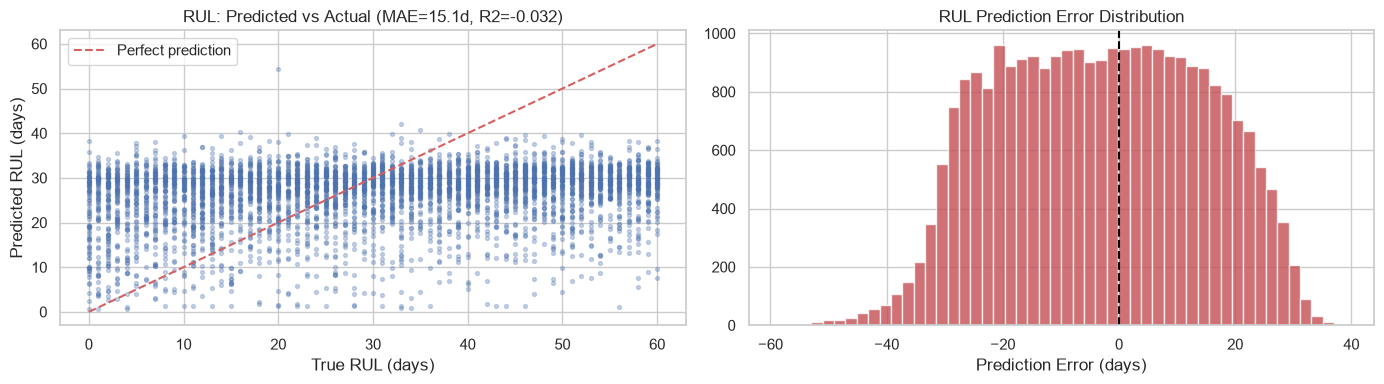

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sample_n = min(5000, len(rul_preds))
idx = np.random.RandomState(RANDOM_STATE).choice(len(rul_preds), size=sample_n, replace=False)
axes[0].scatter(rul_targets[idx], rul_preds[idx], alpha=0.3, s=8, color="#4C72B0")
axes[0].plot([0, RUL_HORIZON_DAYS], [0, RUL_HORIZON_DAYS], "r--", label="Perfect prediction")
axes[0].set_xlabel("True RUL (days)")
axes[0].set_ylabel("Predicted RUL (days)")
axes[0].set_title(f"RUL: Predicted vs Actual (MAE={rul_mae:.1f}d, R2={rul_r2:.3f})")
axes[0].legend()

errors = rul_preds - rul_targets
axes[1].hist(errors, bins=50, color="#C44E52", alpha=0.8)
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_xlabel("Prediction Error (days)")
axes[1].set_title("RUL Prediction Error Distribution")

plt.tight_layout()
plt.show()

## RUL Regression — XGBoost Comparison

Same idea as Section 16b: an `XGBRegressor` on the identical RUL features and splits,
scored with the same MAE / RMSE / R² as the DNN regressor.

In [56]:
from xgboost import XGBRegressor

XGB_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

xgb_rul = XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    eval_metric="mae", early_stopping_rounds=30, random_state=RANDOM_STATE,
    n_jobs=-1, tree_method="hist", device=XGB_DEVICE,
)
xgb_rul.fit(X_rul_train_imp, y_rul_train, eval_set=[(X_rul_val_imp, y_rul_val)], verbose=False)
xgb_rul.set_params(device="cpu")

xgb_rul_preds = np.clip(xgb_rul.predict(X_rul_test_imp), 0, RUL_HORIZON_DAYS)
xgb_rul_mae = np.mean(np.abs(xgb_rul_preds - y_rul_test))
xgb_rul_rmse = np.sqrt(np.mean((xgb_rul_preds - y_rul_test) ** 2))
xgb_rul_r2 = 1 - np.sum((y_rul_test - xgb_rul_preds) ** 2) / np.sum((y_rul_test - np.mean(y_rul_test)) ** 2)

print("=" * 50)
print("   XGBOOST RUL REGRESSION -- TEST SET EVALUATION")
print("=" * 50)
print(f" MAE  (avg days off):  {xgb_rul_mae:.2f} days")
print(f" RMSE:                 {xgb_rul_rmse:.2f} days")
print(f" R-squared:            {xgb_rul_r2:.3f}")

   XGBOOST RUL REGRESSION -- TEST SET EVALUATION
 MAE  (avg days off):  14.22 days
 RMSE:                 16.79 days
 R-squared:            0.088


In [57]:
rul_comparison_df = pd.DataFrame({
    "Metric": ["MAE (days)", "RMSE (days)", "R-squared"],
    "DNN": [rul_mae, rul_rmse, rul_r2],
    "XGBoost": [xgb_rul_mae, xgb_rul_rmse, xgb_rul_r2],
}).round(4)
rul_comparison_df["Winner"] = [
    "XGBoost" if xgb_rul_mae < rul_mae else ("DNN" if xgb_rul_mae > rul_mae else "Tie"),
    "XGBoost" if xgb_rul_rmse < rul_rmse else ("DNN" if xgb_rul_rmse > rul_rmse else "Tie"),
    "XGBoost" if xgb_rul_r2 > rul_r2 else ("DNN" if xgb_rul_r2 < rul_r2 else "Tie"),
]
print(rul_comparison_df.to_string(index=False))

xgb_rul.save_model(f"{MODELS_DIR}/toshiba_rul_xgb.json")
print(f"\nSaved: {MODELS_DIR}/toshiba_rul_xgb.json")

     Metric     DNN  XGBoost  Winner
 MAE (days) 15.0771  14.2232 XGBoost
RMSE (days) 17.8568  16.7889 XGBoost
  R-squared -0.0320   0.0877 XGBoost

Saved: toshiba_rul_xgb.json


In [58]:
torch.save(final_rul_model.state_dict(), f"{MODELS_DIR}/toshiba_rul_dnn.pth")

rul_preprocessing_config = {
    "dataset": "Toshiba export (toshiba_drivestats.parquet)",
    "feature_columns": FEATURE_COLUMNS,
    "base_attributes": ATTRS,
    "input_window_days": INPUT_WINDOW_DAYS,
    "delta_lags": list(DELTA_LAGS),
    "best_config": {
        "hidden_sizes": list(rul_hidden),
        "dropout": float(RUL_BEST_CONFIG["dropout"]),
        "lr": float(RUL_BEST_CONFIG["lr"]),
    },
    "rul_horizon_days": RUL_HORIZON_DAYS,
    "test_mae_days": float(rul_mae),
    "test_rmse_days": float(rul_rmse),
    "test_r2": float(rul_r2),
    "scaler_mean": rul_scaler.mean_.tolist(),
    "scaler_scale": rul_scaler.scale_.tolist(),
    "imputer_statistics": rul_imputer.statistics_.tolist(),
}

with open(f"{MODELS_DIR}/toshiba_rul_preprocessing_config.json", "w") as f:
    json.dump(rul_preprocessing_config, f, indent=2)

print(f"Saved: {MODELS_DIR}/toshiba_rul_dnn.pth")
print(f"Saved: {MODELS_DIR}/toshiba_rul_preprocessing_config.json")

Saved: toshiba_rul_dnn.pth
Saved: toshiba_rul_preprocessing_config.json


---
## Scoring a Live Drive from its Last 90 Days

The Backblaze notebook took *today's* reading and kept a rolling JSON history so it
could reconstruct one 7-day delta. With a 90-day input that indirection is no longer
worth it: the caller hands over the drive's trailing history directly — today plus the
90 preceding daily readings — and `score_drive()` rebuilds exactly the feature vector
Section 4 built, in exactly the same column order.

In [59]:
# ============================================================
# TOSHIBA: DRIVE HEALTH + DAYS-TO-REPLACEMENT PREDICTOR
# ============================================================
CLF_CFG = json.load(open(f"{MODELS_DIR}/toshiba_preprocessing_config.json"))
RUL_CFG = json.load(open(f"{MODELS_DIR}/toshiba_rul_preprocessing_config.json"))

SCORE_ATTRS = CLF_CFG["base_attributes"]
SCORE_W = CLF_CFG["input_window_days"]
SCORE_LAGS = CLF_CFG["delta_lags"]
SCORE_FEATURES = CLF_CFG["feature_columns"]
SCORE_THRESHOLD = CLF_CFG["decision_threshold"]

clf_med = np.array(CLF_CFG["imputer_statistics"])
clf_mean = np.array(CLF_CFG["scaler_mean"])
clf_scale = np.array(CLF_CFG["scaler_scale"])
rul_med = np.array(RUL_CFG["imputer_statistics"])
rul_mean = np.array(RUL_CFG["scaler_mean"])
rul_scale = np.array(RUL_CFG["scaler_scale"])


def build_window_features(history, model_name, capacity_bytes):
    """Rebuild the Section 4 feature row from one drive's trailing history.

    history : DataFrame with a `time` column and the SMART raw attributes, one row per
              day, oldest first. Needs SCORE_W + 1 rows to fill every feature; shorter
              histories still score, with the unavailable long-lag deltas left NaN for
              the imputer -- and a warning, because that is a weaker prediction.
    """
    h = history.sort_values("time").reset_index(drop=True)
    n = len(h)
    feats = {}

    for c in SCORE_ATTRS:
        series = h[c] if c in h.columns else pd.Series([np.nan] * n)
        feats[c] = series.iloc[-1]
        for lag in SCORE_LAGS:
            feats[f"{c}_d{lag}"] = (series.iloc[-1] - series.iloc[-1 - lag]) if n > lag else np.nan
        window = series.iloc[-SCORE_W:]
        feats[f"{c}_mean{SCORE_W}"] = window.mean()
        feats[f"{c}_std{SCORE_W}"] = window.std()
        feats[f"{c}_max{SCORE_W}"] = window.max()

    feats["window_span_days"] = (h["time"].iloc[-1] - h["time"].iloc[-1 - SCORE_W]).days if n > SCORE_W else np.nan
    feats["drive_age_days"] = (h["time"].iloc[-1] - h["time"].iloc[0]).days
    feats["capacity_tb"] = capacity_bytes / 1e12
    for col in SCORE_FEATURES:
        if col.startswith("model_"):
            feats[col] = 1.0 if col == f"model_{model_name}" else 0.0

    x = np.array([[float(feats.get(c, np.nan)) for c in SCORE_FEATURES]])
    return x, n


def score_drive(serial_number, history, model_name, capacity_bytes, verbose=True):
    """Health classification + days-to-replacement for one drive, from its last 90 days."""
    x, n = build_window_features(history, model_name, capacity_bytes)
    if n < SCORE_W + 1 and verbose:
        print(f"WARNING: only {n} readings supplied, {SCORE_W + 1} needed for a full "
              f"{SCORE_W}-day window -- long-lag features are imputed, prediction is weaker.\n")

    def prep(x_raw, med, mean, scale):
        x_filled = np.where(np.isnan(x_raw), med, x_raw)
        return torch.tensor((x_filled - mean) / scale, dtype=torch.float32).to(device)

    final_model.eval()
    final_rul_model.eval()
    with torch.no_grad():
        probability = torch.sigmoid(final_model(prep(x, clf_med, clf_mean, clf_scale))).cpu().item()
        predicted_days = final_rul_model(prep(x, rul_med, rul_mean, rul_scale)).cpu().item()
    predicted_days = float(np.clip(predicted_days, 0, RUL_CFG["rul_horizon_days"]))

    if probability >= SCORE_THRESHOLD:
        prediction = "AT-RISK"
        if probability >= 0.90:
            risk, action = "CRITICAL", "Immediate inspection/replacement recommended."
        elif probability >= 0.70:
            risk, action = "HIGH", "Schedule inspection/replacement soon."
        else:
            risk, action = "MEDIUM", "Monitor drive closely."
    else:
        prediction, risk, action = "HEALTHY / LOW RISK", "LOW", "No immediate action required."

    if verbose:
        h = history.sort_values("time")
        print("=" * 62)
        print(f"   DRIVE {serial_number}  ({model_name})  --  {h['time'].iloc[-1].date()}")
        print("=" * 62)
        print(f"Input window         : {n} readings, "
              f"{h['time'].iloc[0].date()} -> {h['time'].iloc[-1].date()}")
        print(f"Failure probability  : {probability * 100:.2f}%   (threshold {SCORE_THRESHOLD:.2f})")
        print(f"Prediction           : {prediction}")
        print(f"Risk level           : {risk}")
        print(f"Estimated days until replacement needed : {predicted_days:.1f} days"
              + ("" if prediction == "AT-RISK" else "  (not at-risk -- rough extrapolation, not a countdown)"))
        print(f"\nRecommended action: {action}")
        print("\n" + "-" * 62)
        print(f"SMART CHANGE ACROSS THE {SCORE_W}-DAY WINDOW")
        print("-" * 62)
        for c in SCORE_ATTRS:
            if c not in h.columns or h[c].isna().all():
                continue
            first, last = h[c].iloc[max(0, len(h) - 1 - SCORE_W)], h[c].iloc[-1]
            if pd.isna(first) or pd.isna(last):
                continue
            flag = "  <--" if last != first else ""
            print(f"{c:16s}: {first:>14,.0f} -> {last:>14,.0f}  (delta {last - first:+,.0f}){flag}")

    return {"probability": probability, "prediction": prediction, "risk": risk,
            "action": action, "predicted_days_remaining": predicted_days,
            "readings_supplied": n}

In [60]:
# Demo on real drives from the held-out test split: one that failed shortly after the
# scored date, and one healthy drive -- pulled from raw_df so the function receives the
# same shape of input a production caller would.
demo_rows = []
at_risk_pool = test_meta[(test_meta["target"] == 1) & (test_meta["days_to_failure"].between(5, 20))]
healthy_pool = test_meta[test_meta["days_to_failure"].isna()]

for label, pool in [("a drive that failed days later", at_risk_pool), ("a healthy drive", healthy_pool)]:
    if len(pool) == 0:
        continue
    pick = pool.sample(1, random_state=RANDOM_STATE).iloc[0]
    hist = raw_df[(raw_df["id"] == pick["id"]) & (raw_df["time"] <= pick["time"])].tail(SCORE_W + 1)
    print(f"\n########## {label} ##########")
    res = score_drive(pick["id"], hist, pick["model"],
                      capacity_bytes=float(hist["capacity_bytes"].iloc[-1]))
    truth = "AT-RISK" if pick["target"] == 1 else "HEALTHY"
    print(f"\nGround truth: {truth}"
          + (f" (failed {pick['days_to_failure']:.0f} days after this reading)" if pick["target"] == 1 else ""))
    demo_rows.append({"drive": pick["id"], "model": pick["model"].replace("TOSHIBA ", ""),
                      "truth": truth, "predicted": res["prediction"],
                      "probability": round(res["probability"], 4),
                      "days_remaining": round(res["predicted_days_remaining"], 1)})

pd.DataFrame(demo_rows)


########## a drive that failed days later ##########
   DRIVE 43Q0A05WFVKG  (TOSHIBA MG08ACA16TA)  --  2025-03-20
Input window         : 91 readings, 2024-12-20 -> 2025-03-20
Failure probability  : 39.42%   (threshold 0.92)
Prediction           : HEALTHY / LOW RISK
Risk level           : LOW
Estimated days until replacement needed : 27.1 days  (not at-risk -- rough extrapolation, not a countdown)

Recommended action: No immediate action required.

--------------------------------------------------------------
SMART CHANGE ACROSS THE 90-DAY WINDOW
--------------------------------------------------------------
smart_3_raw     :          8,181 ->          8,181  (delta +0)
smart_4_raw     :              9 ->              9  (delta +0)
smart_5_raw     :              0 ->              0  (delta +0)
smart_9_raw     :         10,167 ->         12,334  (delta +2,167)  <--
smart_12_raw    :              9 ->              9  (delta +0)
smart_192_raw   :              8 ->              8  (delta 

,drive,model,truth,predicted,probability,days_remaining
0,43Q0A05WFVKG,MG08ACA16TA,AT-RISK,HEALTHY / LOW RISK,0.3942,27.1
1,6240A2W3FVKG,MG08ACA16TA,HEALTHY,HEALTHY / LOW RISK,0.5408,28.7


## Summary: DNN vs. XGBoost — Which Should the Client Use?

Both models were trained and evaluated on **identical** features, splits, and metrics,
so the tables in Section 16b and the RUL comparison are apples-to-apples rather than a
reason to prefer one on vibes. For a tabular problem like this one — engineered
window features, heavy class imbalance, a few million rows — gradient-boosted trees
tend to match or beat DNNs, train in under a minute rather than tens of them, need far
less hyperparameter babysitting, and hand you the feature importances that Section 16b
uses to show *where the 90-day window earns its keep*. The numbers in those tables, not
that general rule, are the deciding evidence.

## 17. Conclusions, Limitations & Future Work

### What was built

A predictive-maintenance pipeline for **Toshiba** hard drives, trained on the local
`Toshiba/` export rather than on downloaded Backblaze quarters:

1. **Data layer** — `scripts/build_toshiba_parquet.py` folds 105 Excel workbooks
   (0.7 GB, 197 columns, 3.2M drive-days across 14 drive models) into a single 34 MB
   parquet file with a pinned schema. Every re-run reads that instead of Excel.
2. **90-day input window** — each prediction is made from a drive's trailing 90 days:
   per SMART attribute the current level, 7/30/90-day deltas, and the window's
   mean/std/max, plus window context and a one-hot of the drive model. Rows without a
   genuine full window are dropped rather than median-filled into looking complete.
3. **Failure Classifier** — binary DNN + XGBoost predicting failure within
   `FAILURE_HORIZON_DAYS` days, with class-weighted / focal loss and a threshold tuned
   on validation only.
4. **RUL Regressor** — DNN + XGBoost estimating days-to-failure inside a
   `RUL_HORIZON_DAYS` window.
5. **Cross-model analysis** (Section 16c) — per-family performance, pooled vs.
   family-only training, and a leave-one-model-out test of transfer to an unseen family.

### What is specific to Toshiba

The Seagate feature list does not carry over. `smart_187`, `smart_188` and `smart_241` —
three of the nine attributes the Backblaze notebook is built on — are **not reported at
all** by these Toshiba families, and roughly a third of the attributes Toshiba does
report are constant across the entire fleet and therefore useless. Section 2a derives
the feature list from the data instead, which is the step that has to be repeated for
any new manufacturer.

### The finding that mattered most

Both learners were being held back by the same mistake, reached two different ways:
**correcting the class imbalance twice**. The DNN drew class-balanced batches from a
`WeightedRandomSampler` *and* applied `pos_weight` to the loss; XGBoost was given
`scale_pos_weight` equal to the raw class ratio. In both cases the over-correction
hurts, because every headline metric here (PR-AUC, Precision@K) scores the *ranking* of
drives, and inflating the positive class distorts the gradient without improving that
ranking. Section 10 and Section 16b now measure the imbalance strategy rather than
assuming one, which is the single change that moved the numbers most.

### Limitations

- **The export is a cohort, not the fleet.** Every failed drive is included plus a
  matched sample of healthy drives, so the class balance here is far kinder than in
  production. Ranking metrics (PR-AUC, Precision@K) transfer; the absolute positive
  rate does not.
- **Three families have zero failures** in the export, so nothing can be learned about
  them and they only ever contribute negatives.
- **The 90-day window costs coverage at the edges**: a drive's first 90 days are
  unscoreable, which is precisely the infant-mortality period.
- `EXTENDED_ATTRS` are missing entirely for the two "EY" families and get median-filled
  from other families' distributions. The drive-model one-hot lets the models
  compensate, but a per-family imputation would be cleaner.
- The RUL model only sees drives that failed, so at inference its output is meaningful
  only for drives the classifier has already flagged.

### Future work

- Sequence models (LSTM / 1D-CNN / Transformer) consuming the raw 90-day sequence
  directly instead of the hand-engineered window summaries — the window features here
  are a strong baseline for exactly that comparison.
- Per-family calibration on top of the pooled model, given the Section 16c spread.
- Query `drivestats.duckdb` for the full Toshiba fleet rather than the exported cohort,
  which would fix the base-rate distortion noted above.
- Extend the same 90-day pipeline to the Seagate data and compare manufacturers under
  one protocol.